# Efficiency Wages with Motivated Agents: Analysis Walkthrough

This notebook runs the analysis for the paper and online appendix from the public raw CSV inputs. It uses Python for data assembly, summary tables, and figures, and `pystata` for the regression tables.

Publication: https://www.sciencedirect.com/science/article/pii/S0899825624000307?via%3Dihub

## 1. Setup

The notebook uses the same source code as the script workflow. If Stata is not found automatically, set `STATA_PATH` to the full Stata executable path before starting Jupyter.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from src.analysis.figures import build as build_figures
from src.analysis.format_tables import build as format_table_outputs
from src.analysis.tables_appendix import build as build_appendix_summary_tables
from src.data.assemble import build as assemble_data
from src.paths import APPENDIX_FIGURES, APPENDIX_TABLES, PAPER_FIGURES, PAPER_TABLES, RAW_COMBINED
from src.stata import configure_pystata, pystata_config

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
ROOT = Path.cwd()

## 2. Raw Data

The analysis starts from the treatment-level `combined.csv` files in `data/raw`.

In [2]:
raw_summary = []
for name, path in RAW_COMBINED.items():
    frame = pd.read_csv(path)
    raw_summary.append({"input": name, "path": str(path.relative_to(ROOT)), "rows": len(frame), "columns": len(frame.columns)})

display(pd.DataFrame(raw_summary))

,input,path,rows,columns
0,ge_prosocial,data/raw/ge_prosocial/combined.csv,190,176
1,neutral,data/raw/neutral/combined.csv,90,191
2,efficiency,data/raw/efficiency/combined.csv,120,169


## 3. Assemble Analysis Data

This step standardizes treatment labels, constructs agent and principal indicators, and reshapes wage-level choices and beliefs into long-form analysis datasets.

In [3]:
sample_counts = assemble_data()
counts_table = pd.DataFrame.from_dict(sample_counts, orient="index").rename_axis("treatment").reset_index()
display(counts_table)

,treatment,observations,agents,principals
0,N,90,45,45
1,P,94,47,47
2,PAN,120,60,60
3,S,96,48,48


## 4. Figures

The following cell regenerates all paper and appendix figures from the derived analysis datasets.

In [4]:
figure_outputs = build_figures()
pd.DataFrame(
    [{"figure_file": name, "path": Path(path).relative_to(ROOT)} for name, path in figure_outputs.items()]
)

,figure_file,path
0,main_fig_2_chosen_effort.png,results/paper/figures/main_fig_2_chosen_effort...
1,main_fig_3_wage_comparisons.png,results/paper/figures/main_fig_3_wage_comparis...
2,main_fig_4_chosen_expected_effort.png,results/paper/figures/main_fig_4_chosen_expect...
3,supp_fig_a1_acceptance_wage.png,results/appendix/figures/supp_fig_a1_acceptanc...
4,supp_fig_a2_chosen_effort_all.png,results/appendix/figures/supp_fig_a2_chosen_ef...
5,supp_fig_a3_wage_comparisons_all.png,results/appendix/figures/supp_fig_a3_wage_comp...
6,supp_fig_a4_beliefs_based_profitmax_wage.png,results/appendix/figures/supp_fig_a4_beliefs_b...
7,supp_fig_a5_individual_effort_ge.png,results/appendix/figures/supp_fig_a5_individua...
8,supp_fig_a6_individual_effort_prosocial.png,results/appendix/figures/supp_fig_a6_individua...
9,supp_fig_a7_individual_effort_neutral.png,results/appendix/figures/supp_fig_a7_individua...


## 5. Stata Regression Tables

The regression tables are estimated in Stata through `pystata`. The setup cell below uses the repository's OS-agnostic Stata resolver, so it works with `STATA_PATH`, Stata on `PATH`, or common Stata installation locations.

In [5]:
install_dir, edition, stata_info = pystata_config()
display(pd.DataFrame([{
    "stata_executable": stata_info.executable,
    "stata_version": stata_info.version,
    "stata_setup_directory": str(install_dir),
    "stata_edition": edition,
}]))

,stata_executable,stata_version,stata_setup_directory,stata_edition
0,/Applications/Stata/StataSE.app/Contents/MacOS...,19,/Applications/Stata,se


In [6]:
# Configure pystata and run the same Stata do-files used by the script workflow.
configure_pystata()
from pystata import stata

build_appendix_summary_tables()
stata.run('do "src/analysis/tables_main.do"')
stata.run('do "src/analysis/tables_appendix.do"')
formatted_tables = format_table_outputs()

pd.DataFrame(
    [{"table": table, "csv": paths["csv"], "tex": paths["tex"]} for table, paths in formatted_tables.items()]
)


. version 19

. set more off

. 
. capture mkdir results

. capture mkdir results/_intermediate

. capture mkdir results/_intermediate/tables

. capture mkdir results/_intermediate/logs

. log using results/_intermediate/logs/stata_main_tables.log, replace text
-------------------------------------------------------------------------------
      name:  <unnamed>
       log:  /Users/jesper/Documents/Workspace/Github/efficiency-wages/results/
> _intermediate/logs/stata_main_tables.log
  log type:  text
 opened on:   7 May 2026, 05:03:33

. 
. tempname results

. postfile `results' str12 table_id str8 model str48 term double coefficient st
> d_error fit_stat observations using results/_intermediate/tables/main_tables_
> results.dta, replace

. 
. import delimited data/derived/agent_wage_long.csv, clear varnames(1)


(encoding automatically selected: ISO-8859-1)


(20 vars, 3,600 obs)

. keep if treatment == "P" | treatment == "S"
(1,890 observations deleted)

. generate treatmentS = treatment == "S"

. generate wage_below_5 = .
(1,710 missing values generated)

. replace wage_below_5 = 0 if wage > 3
(1,520 real changes made)

. replace wage_below_5 = 1 if wage < 5
(190 real changes made)

. xtset n

Panel variable: n (balanced)

. 
. quietly xtreg acceptance c.wage_below_5, re cluster(n)



. post `results' ("Table 2") ("1") ("Wage<5") (_b[wage_below_5]) (_se[wage_belo
> w_5]) (e(r2_o)) (e(N))

. post `results' ("Table 2") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_
> o)) (e(N))

. 
. quietly xtreg acceptance c.wage_below_5##c.treatmentS, re cluster(n)



. post `results' ("Table 2") ("2") ("Wage<5") (_b[wage_below_5]) (_se[wage_belo
> w_5]) (e(r2_o)) (e(N))

. post `results' ("Table 2") ("2") ("Prosocial treatment") (_b[treatmentS]) (_s
> e[treatmentS]) (e(r2_o)) (e(N))

. post `results' ("Table 2") ("2") ("Wage<5*Prosocial treatment") (_b[c.wage_be
> low_5#c.treatmentS]) (_se[c.wage_below_5#c.treatmentS]) (e(r2_o)) (e(N))

. post `results' ("Table 2") ("2") ("Constant") (_b[_cons]) (_se[_cons]) (e(r2_
> o)) (e(N))

. 
. quietly xtreg acceptance c.wage_below_5##c.treatmentS i.gender i.study age, r
> e cluster(n)


...


. post `results' ("Table A.7") ("6") ("Wage") (_b[wage]) (_se[wage]) (e(r2_p)) 
> (e(N))

. post `results' ("Table A.7") ("6") ("GE treatment") (_b[treatment_ge]) (_se[t
> reatment_ge]) (e(r2_p)) (e(N))

. post `results' ("Table A.7") ("6") ("Efficiency treatment") (_b[treatment_eff
> iciency]) (_se[treatment_efficiency]) (e(r2_p)) (e(N))

. post `results' ("Table A.7") ("6") ("Wage*GE treatment") (_b[c.wage#c.treatme
> nt_ge]) (_se[c.wage#c.treatment_ge]) (e(r2_p)) (e(N))

. post `results' ("Table A.7") ("6") ("Wage*Efficiency treatment") (_b[c.wage#c
> .treatment_efficiency]) (_se[c.wage#c.treatment_efficiency]) (e(r2_p)) (e(N))

. post `results' ("Table A.7") ("6") ("Constant") (_b[_cons]) (_se[_cons]) (e(r
> 2_p)) (e(N))

. 
. import delimited data/derived/principals.csv, clear varnames(1)
(encoding automatically selected: ISO-8859-1)


(205 vars, 200 obs)

. keep if treatment == "P" | treatment == "S" | treatment == "N"
(60 observations deleted)

. generate offered_wage = pa_offer_principal

. generate treatment_ge = treatment == "P"

. generate treatment_neutral = treatment == "N"

. generate ge_charity = treatment_ge * dictatorcharity

. generate neutral_charity = treatment_neutral * dictatorcharity

. 
. quietly regress offered_wage treatment_ge treatment_neutral, robust

. post `results' ("Table A.8") ("1") ("GE treatment") (_b[treatment_ge]) (_se[t
> reatment_ge]) (e(r2)) (e(N))

. post `results' ("Table A.8") ("1") ("Neutral treatment") (_b[treatment_neutra
> l]) (_se[treatment_neutral]) (e(r2)) (e(N))

. post `results' ("Table A.8") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r
> 2)) (e(N))

. 
. quietly regress offered_wage treatment_ge treatment_neutral dictatorcharity, 
> robust

. post `results' ("Table A.8") ("2") ("GE treatment") (_b[treatment_ge]) (_se[t
> reatment_ge]) (e(r2)) (e(N))

. post `result

(205 vars, 200 obs)

. keep if treatment == "P" | treatment == "S" | treatment == "PAN"
(45 observations deleted)

. generate offered_wage = pa_offer_principal

. generate treatment_ge = treatment == "P"

. generate treatment_efficiency = treatment == "PAN"

. generate ge_charity = treatment_ge * dictatorcharity

. generate efficiency_charity = treatment_efficiency * dictatorcharity

. 
. quietly regress offered_wage treatment_ge treatment_efficiency, robust

. post `results' ("Table A.9") ("1") ("GE treatment") (_b[treatment_ge]) (_se[t
> reatment_ge]) (e(r2)) (e(N))

. post `results' ("Table A.9") ("1") ("Efficiency treatment") (_b[treatment_eff
> iciency]) (_se[treatment_efficiency]) (e(r2)) (e(N))

. post `results' ("Table A.9") ("1") ("Constant") (_b[_cons]) (_se[_cons]) (e(r
> 2)) (e(N))

. 
. quietly regress offered_wage treatment_ge treatment_efficiency dictatorcharit
> y, robust



. post `results' ("Table A.9") ("2") ("GE treatment") (_b[treatment_ge]) (_se[t
> reatment_ge]) (e(r2)) (e(N))

. post `results' ("Table A.9") ("2") ("Efficiency treatment") (_b[treatment_eff
> iciency]) (_se[treatment_efficiency]) (e(r2)) (e(N))

. post `results' ("Table A.9") ("2") ("Charitable motivation") (_b[dictatorchar
> ity]) (_se[dictatorcharity]) (e(r2)) (e(N))

. post `results' ("Table A.9") ("2") ("Constant") (_b[_cons]) (_se[_cons]) (e(r
> 2)) (e(N))

. 
. quietly regress offered_wage treatment_ge treatment_efficiency dictatorcharit
> y ge_charity efficiency_charity, robust

. post `results' ("Table A.9") ("3") ("GE treatment") (_b[treatment_ge]) (_se[t
> reatment_ge]) (e(r2)) (e(N))

. post `results' ("Table A.9") ("3") ("Efficiency treatment") (_b[treatment_eff
> iciency]) (_se[treatment_efficiency]) (e(r2)) (e(N))

. post `results' ("Table A.9") ("3") ("Charitable motivation") (_b[dictatorchar
> ity]) (_se[dictatorcharity]) (e(r2)) (e(N))

. post `results' ("Table A.9"

,table,csv,tex
0,Table A.1,/Users/jesper/Documents/Workspace/Github/effic...,/Users/jesper/Documents/Workspace/Github/effic...
1,Table 2,/Users/jesper/Documents/Workspace/Github/effic...,/Users/jesper/Documents/Workspace/Github/effic...
2,Table 3,/Users/jesper/Documents/Workspace/Github/effic...,/Users/jesper/Documents/Workspace/Github/effic...
3,Table 4,/Users/jesper/Documents/Workspace/Github/effic...,/Users/jesper/Documents/Workspace/Github/effic...
4,Table A.2,/Users/jesper/Documents/Workspace/Github/effic...,/Users/jesper/Documents/Workspace/Github/effic...
5,Table A.3,/Users/jesper/Documents/Workspace/Github/effic...,/Users/jesper/Documents/Workspace/Github/effic...
6,Table A.4,/Users/jesper/Documents/Workspace/Github/effic...,/Users/jesper/Documents/Workspace/Github/effic...
7,Table A.5,/Users/jesper/Documents/Workspace/Github/effic...,/Users/jesper/Documents/Workspace/Github/effic...
8,Table A.6,/Users/jesper/Documents/Workspace/Github/effic...,/Users/jesper/Documents/Workspace/Github/effic...
9,Table A.7,/Users/jesper/Documents/Workspace/Github/effic...,/Users/jesper/Documents/Workspace/Github/effic...


## 6. Main Paper Tables

These are the generated versions of Tables 2-4.

In [7]:
paper_tables = [
    ("Table 2. Acceptance", PAPER_TABLES / "table_2_acceptance.csv"),
    ("Table 3. Effort", PAPER_TABLES / "table_3_effort.csv"),
    ("Table 4. Wage offers", PAPER_TABLES / "table_4_wage_offers.csv"),
]

for title, path in paper_tables:
    display(Markdown(f"### {title}"))
    display(pd.read_csv(path))

### Table 2. Acceptance

,Term,1,2,3,4,5,6
0,Wage<5,-0.707***,-0.759***,-0.759***,-5.417***,-6.474***,-6.517***
1,NaN,(0.033),(0.040),(0.040),(0.402),(0.756),(0.753)
2,Constant,0.818***,0.802***,0.757***,2.237***,2.012***,1.333
3,NaN,(0.021),(0.033),(0.147),(0.253),(0.284),(1.386)
4,Prosocial treatment,NaN,0.031,0.035,NaN,0.415,0.477
5,NaN,NaN,(0.041),(0.040),NaN,(0.426),(0.418)
6,Wage<5*Prosocial treatment,NaN,0.103,0.103,NaN,1.667*,1.714*
7,NaN,NaN,(0.065),(0.065),NaN,(0.908),(0.904)
8,Observations,1710,1710,1710,1710,1710,1710
9,R-squared / pseudo R-squared,0.256,0.260,0.263,NaN,NaN,NaN


### Table 3. Effort

,Term,1,2,3,4,5,6
0,Wage,0.089***,0.091***,0.091***,0.138***,0.145***,0.145***
1,NaN,(0.005),(0.007),(0.007),(0.008),(0.011),(0.011)
2,Constant,0.620***,0.242*,-2.993**,-1.826***,-2.552***,-7.608***
3,NaN,(0.157),(0.142),(1.239),(0.360),(0.413),(1.946)
4,Prosocial treatment,NaN,0.749**,0.634*,NaN,1.431**,1.340*
5,NaN,NaN,(0.302),(0.374),NaN,(0.626),(0.707)
6,Wage*Prosocial treatment,NaN,-0.004,-0.004,NaN,-0.013,-0.014
7,NaN,NaN,(0.009),(0.009),NaN,(0.016),(0.016)
8,Observations,1710,1710,1710,1710,1710,1710
9,R-squared / pseudo R-squared,0.459,0.466,0.491,0.138,0.141,0.150


### Table 4. Wage offers

,Term,1,2,3,4
0,Prosocial treatment,10.196***,10.187**,14.593**,13.218**
1,NaN,(3.952),(3.958),(5.668),(5.669)
2,Constant,25.574***,24.072***,21.740***,21.360
3,NaN,(2.443),(3.161),(3.589),(13.294)
4,Charitable motivation,NaN,0.098,0.250**,0.145
5,NaN,NaN,(0.110),(0.124),(0.149)
6,Prosocial treatment*Charitable motivation,NaN,NaN,-0.287,-0.182
7,NaN,NaN,NaN,(0.204),(0.203)
8,Observations,95,95,95,95
9,R-squared / pseudo R-squared,0.066,0.073,0.088,0.115


## 7. Main Paper Figures

These are the generated versions of Figures 2-4.

### Figure 2. Chosen effort

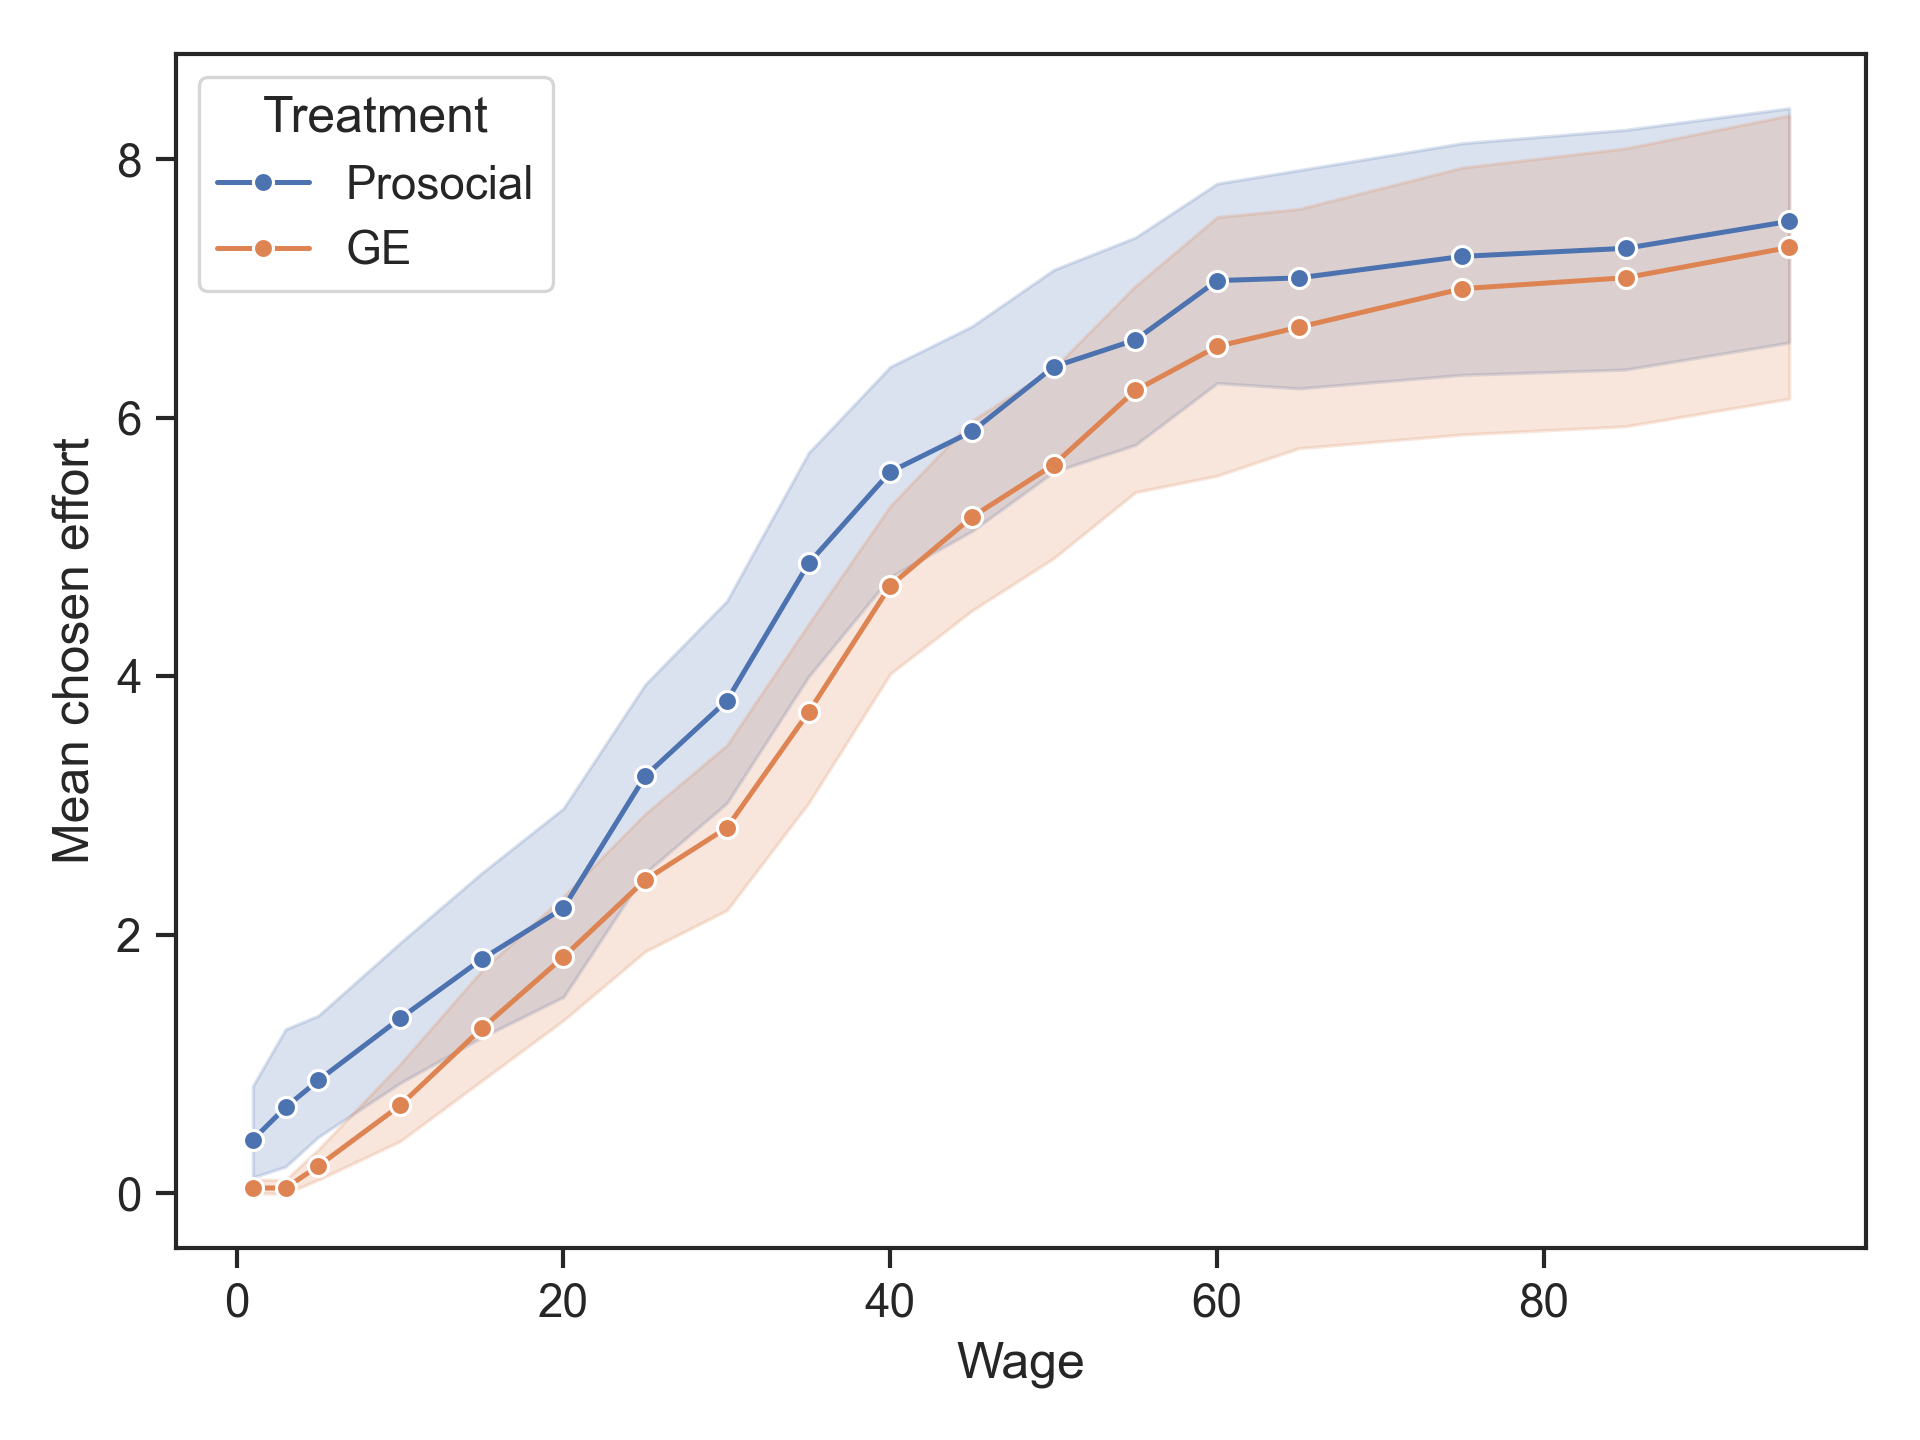

### Figure 3. Wage comparisons

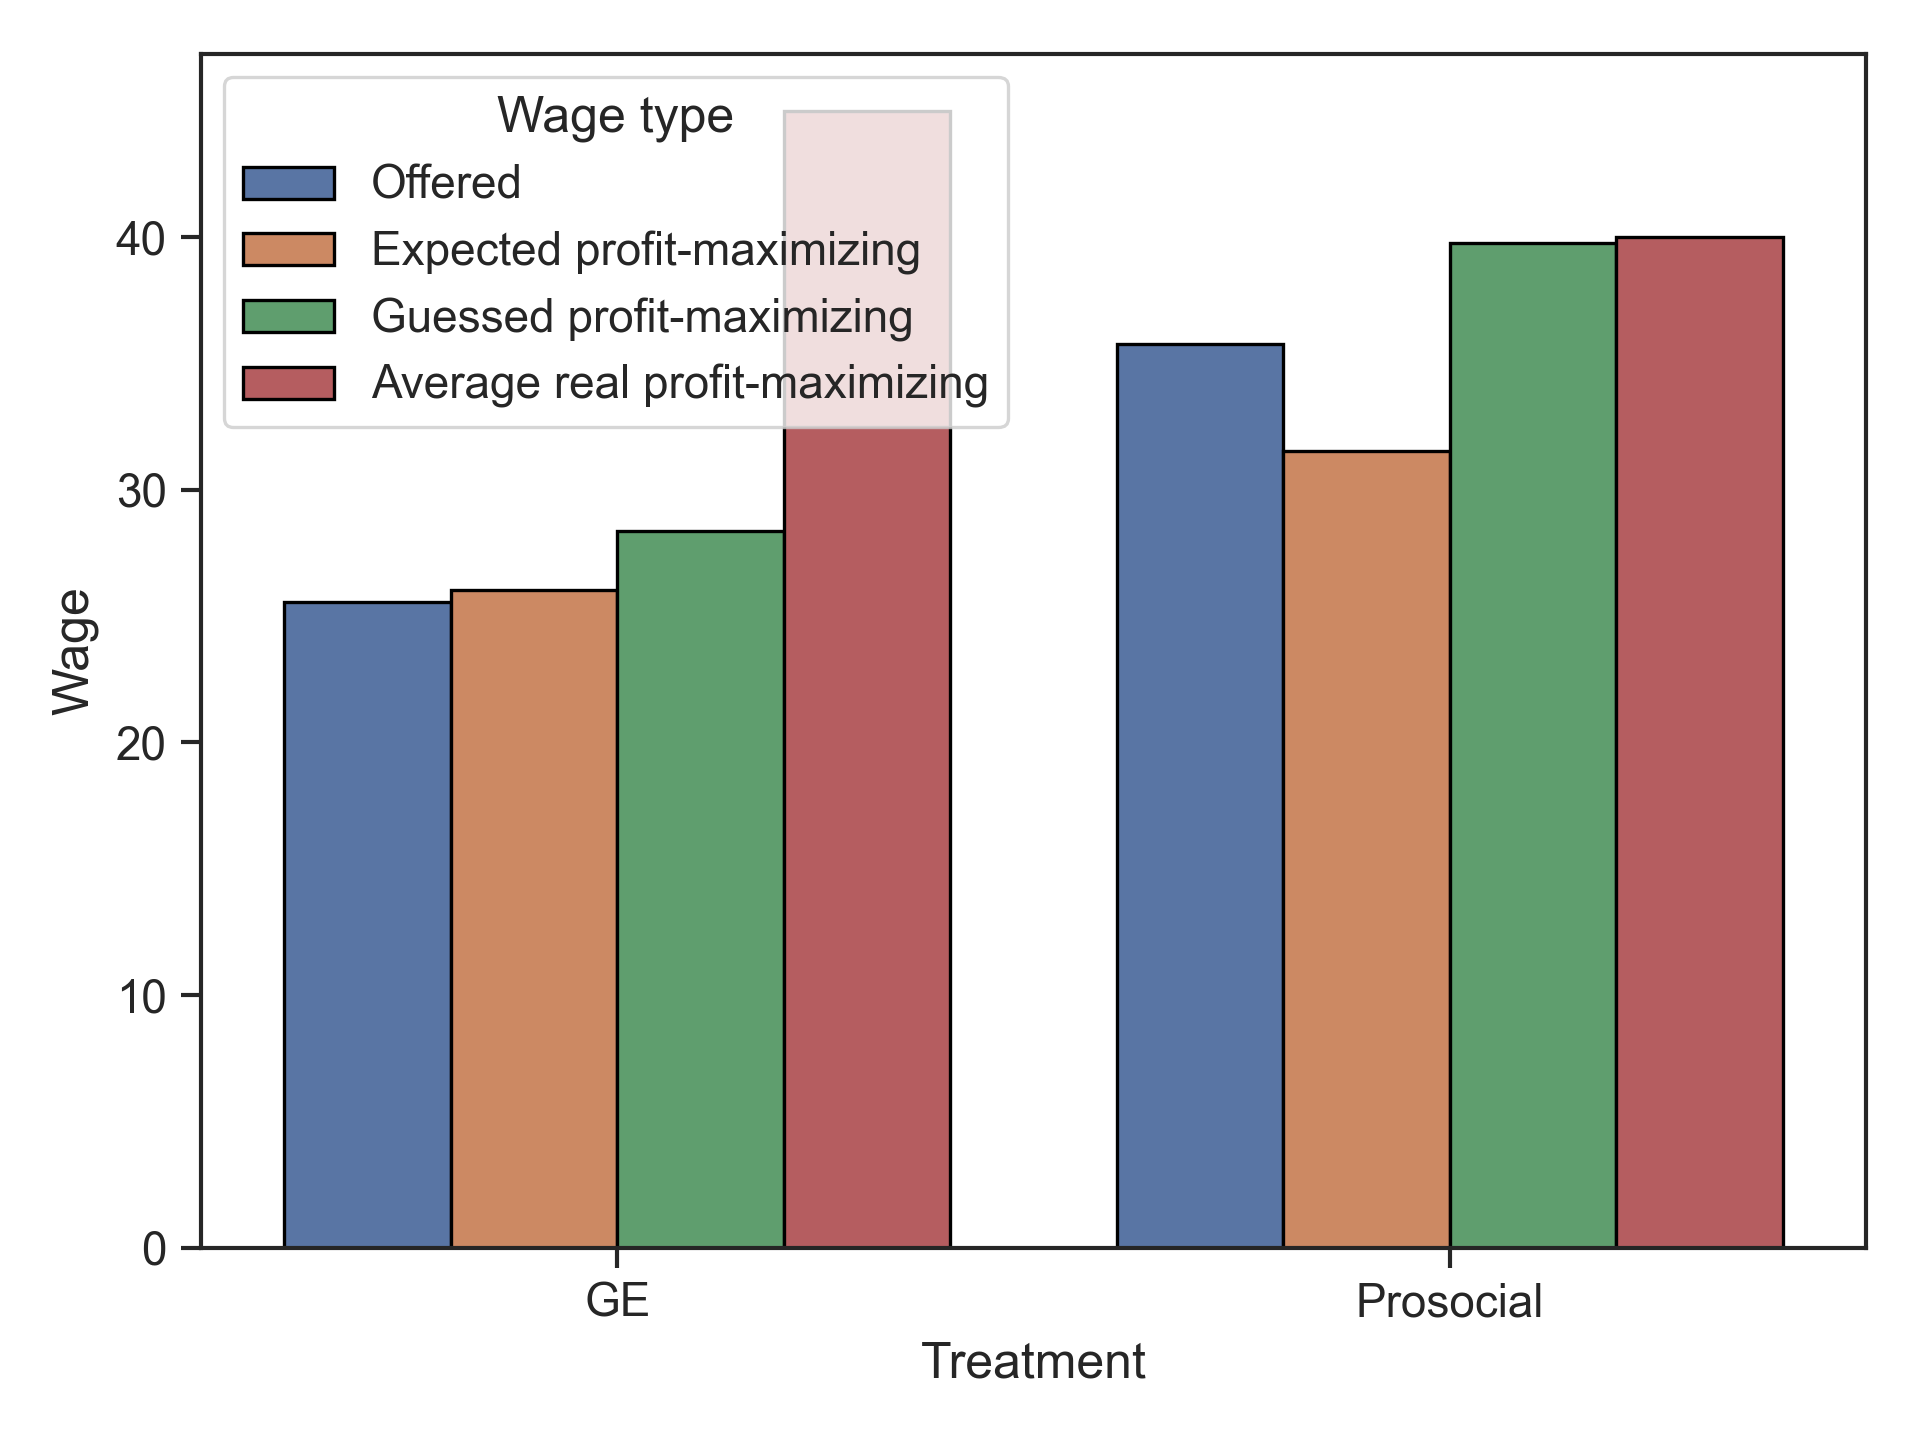

### Figure 4. Chosen and expected effort

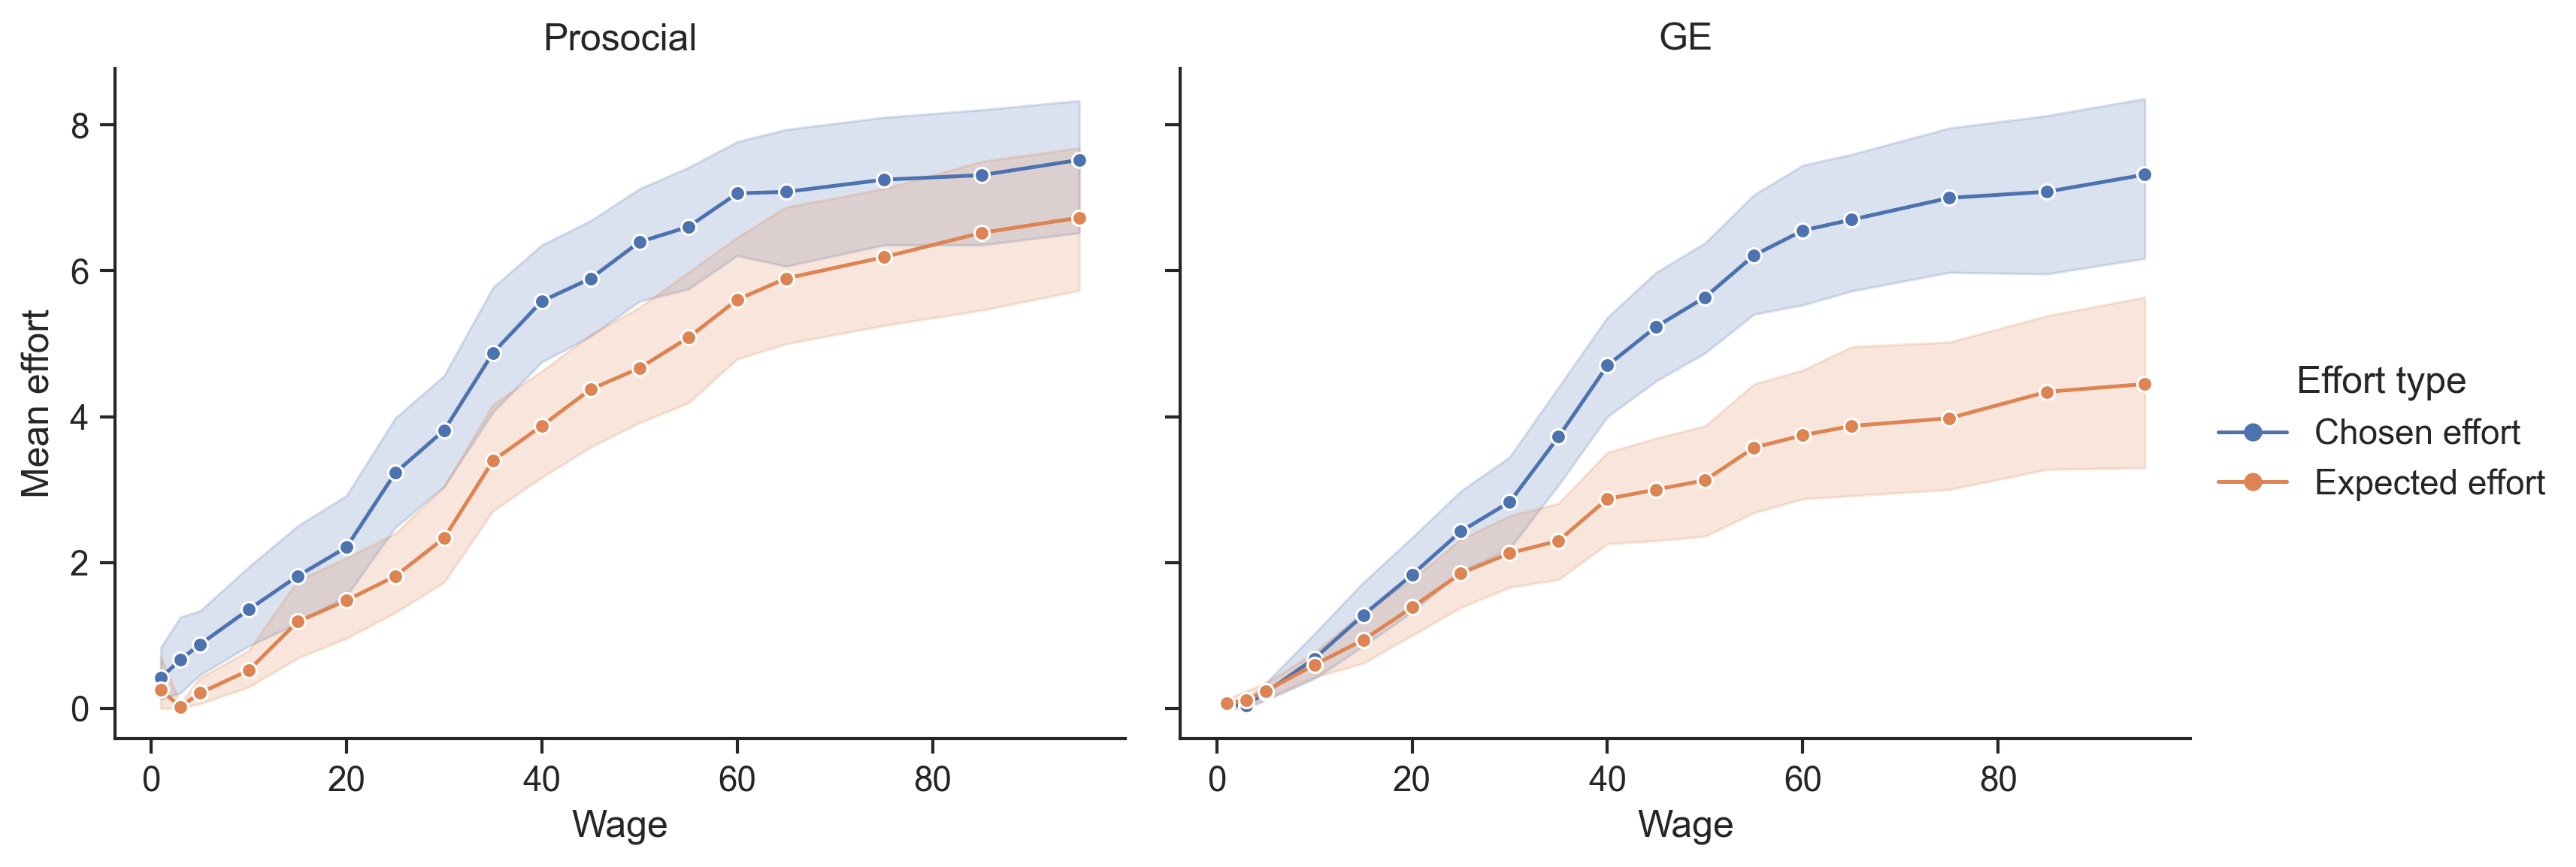

In [8]:
paper_figures = [
    ("Figure 2. Chosen effort", PAPER_FIGURES / "main_fig_2_chosen_effort.png"),
    ("Figure 3. Wage comparisons", PAPER_FIGURES / "main_fig_3_wage_comparisons.png"),
    ("Figure 4. Chosen and expected effort", PAPER_FIGURES / "main_fig_4_chosen_expected_effort.png"),
]

for title, path in paper_figures:
    display(Markdown(f"### {title}"))
    display(Image(filename=str(path)))

## 8. Online Appendix Tables

These are the generated versions of Tables A.1-A.9.

In [9]:
appendix_tables = [
    ("Table A.1. Summary statistics", APPENDIX_TABLES / "table_a1_summary_statistics.csv"),
    ("Table A.2. Effort, GE and prosocial", APPENDIX_TABLES / "table_a2_effort_ge_prosocial.csv"),
    ("Table A.3. Effort, neutral and efficiency", APPENDIX_TABLES / "table_a3_effort_neutral_efficiency.csv"),
    ("Table A.4. Acceptance, neutral", APPENDIX_TABLES / "table_a4_acceptance_neutral.csv"),
    ("Table A.5. Acceptance, efficiency", APPENDIX_TABLES / "table_a5_acceptance_efficiency.csv"),
    ("Table A.6. Effort, neutral", APPENDIX_TABLES / "table_a6_effort_neutral.csv"),
    ("Table A.7. Effort, efficiency", APPENDIX_TABLES / "table_a7_effort_efficiency.csv"),
    ("Table A.8. Wage offers, neutral", APPENDIX_TABLES / "table_a8_wage_offers_neutral.csv"),
    ("Table A.9. Wage offers, efficiency", APPENDIX_TABLES / "table_a9_wage_offers_efficiency.csv"),
]

for title, path in appendix_tables:
    display(Markdown(f"### {title}"))
    display(pd.read_csv(path))

### Table A.1. Summary statistics

,Variable,GE,Prosocial,Neutral,Efficiency
0,Age,24.362 (3.849),24.208 (4.052),25.389 (4.749),25.775 (6.627)
1,Male,0.564 (0.499),0.677 (0.470),0.567 (0.498),0.567 (0.498)
2,Study subject #1,0.170 (0.378),0.177 (0.384),0.156 (0.364),0.217 (0.414)
3,Study subject #2,0.213 (0.411),0.198 (0.401),0.189 (0.394),0.192 (0.395)
4,Study subject #3,0.617 (0.489),0.625 (0.487),0.656 (0.478),0.592 (0.494)
5,N,94,96,90,120


### Table A.2. Effort, GE and prosocial

,Term,GE real,Prosocial real,GE expected,Prosocial expected
0,Wage,0.091***,0.087***,0.051***,0.082***
1,NaN,(0.007),(0.007),(0.007),(0.007)
2,Constant,0.242*,0.991***,0.327***,0.108
3,NaN,(0.142),(0.268),(0.107),(0.159)
4,Observations,846,864,846,864
5,R-squared / pseudo R-squared,0.494,0.432,0.247,0.446


### Table A.3. Effort, neutral and efficiency

...

,Term,1,2,3,4,5,6
0,Wage,0.081***,0.087***,0.087***,0.128***,0.128***,0.127***
1,NaN,(0.004),(0.007),(0.007),(0.006),(0.011),(0.011)
2,Constant,0.344**,0.991***,-0.430,-2.308***,-0.955*,-2.910**
3,NaN,(0.135),(0.267),(0.931),(0.293),(0.501),(1.344)
4,GE treatment,NaN,-0.749**,-0.575*,NaN,-1.389**,-1.163*
5,NaN,NaN,(0.302),(0.349),NaN,(0.600),(0.646)
6,Efficiency treatment,NaN,-1.085***,-0.943**,NaN,-2.225***,-2.030***
7,NaN,NaN,(0.356),(0.390),NaN,(0.747),(0.771)
8,Wage*GE treatment,NaN,0.004,0.004,NaN,0.013,0.013
9,NaN,NaN,(0.009),(0.009),NaN,(0.015),(0.015)


### Table A.8. Wage offers, neutral

,Term,1,2,3,4
0,GE treatment,-10.196***,-10.189***,-14.593**,-14.148**
1,NaN,(3.953),(3.952),(5.670),(5.629)
2,Neutral treatment,-0.571,-0.723,-1.930,-1.639
3,NaN,(4.174),(4.184),(5.683),(5.621)
4,Constant,35.771***,34.548***,36.333***,27.210**
5,NaN,(3.107),(3.519),(4.388),(12.794)
6,Charitable motivation,NaN,0.079,-0.036,-0.052
7,NaN,NaN,(0.086),(0.162),(0.173)
8,GE treatment*Charitable motivation,NaN,NaN,0.287,0.245
9,NaN,NaN,NaN,(0.204),(0.205)


### Table A.9. Wage offers, efficiency

,Term,1,2,3,4
0,GE treatment,-10.196***,-10.185***,-14.593***,-14.187**
1,NaN,(3.948),(3.947),(5.658),(5.750)
2,Efficiency treatment,10.913**,9.776**,6.797,6.658
3,NaN,(4.538),(4.536),(6.619),(6.726)
4,Constant,35.771***,33.911***,36.333***,42.458***
5,NaN,(3.103),(3.573),(4.379),(9.948)
6,Charitable motivation,NaN,0.121,-0.036,-0.014
7,NaN,NaN,(0.100),(0.162),(0.156)
8,GE treatment*Charitable motivation,NaN,NaN,0.287,0.162
9,NaN,NaN,NaN,(0.204),(0.199)


## 9. Online Appendix Figures

These are the generated versions of Figures A.1-A.8.

### Figure A.1. Acceptance by wage

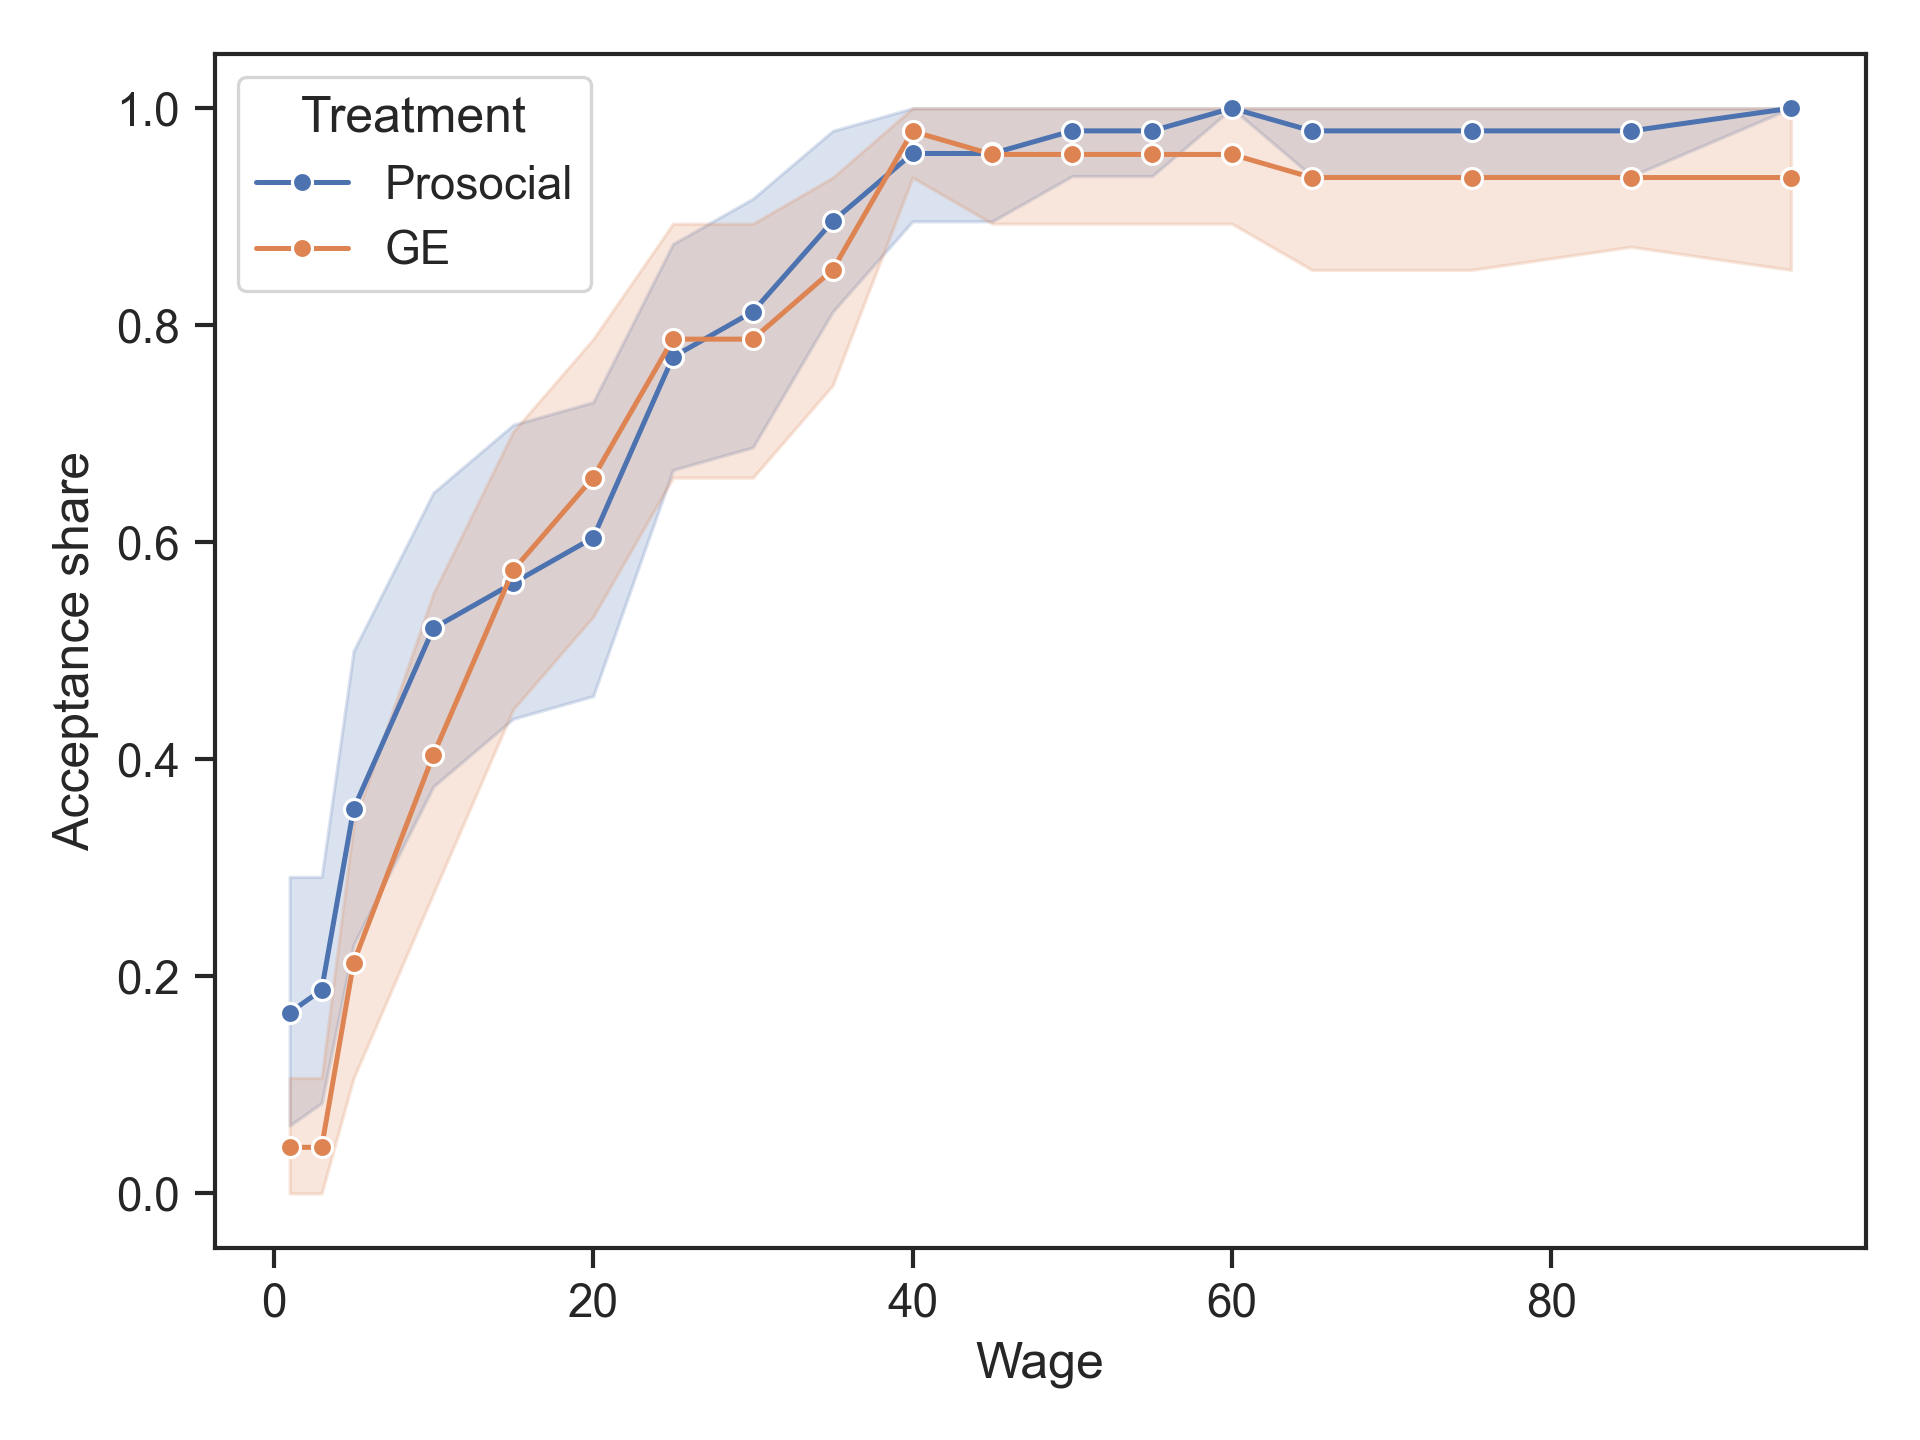

### Figure A.2. Chosen effort, all treatments

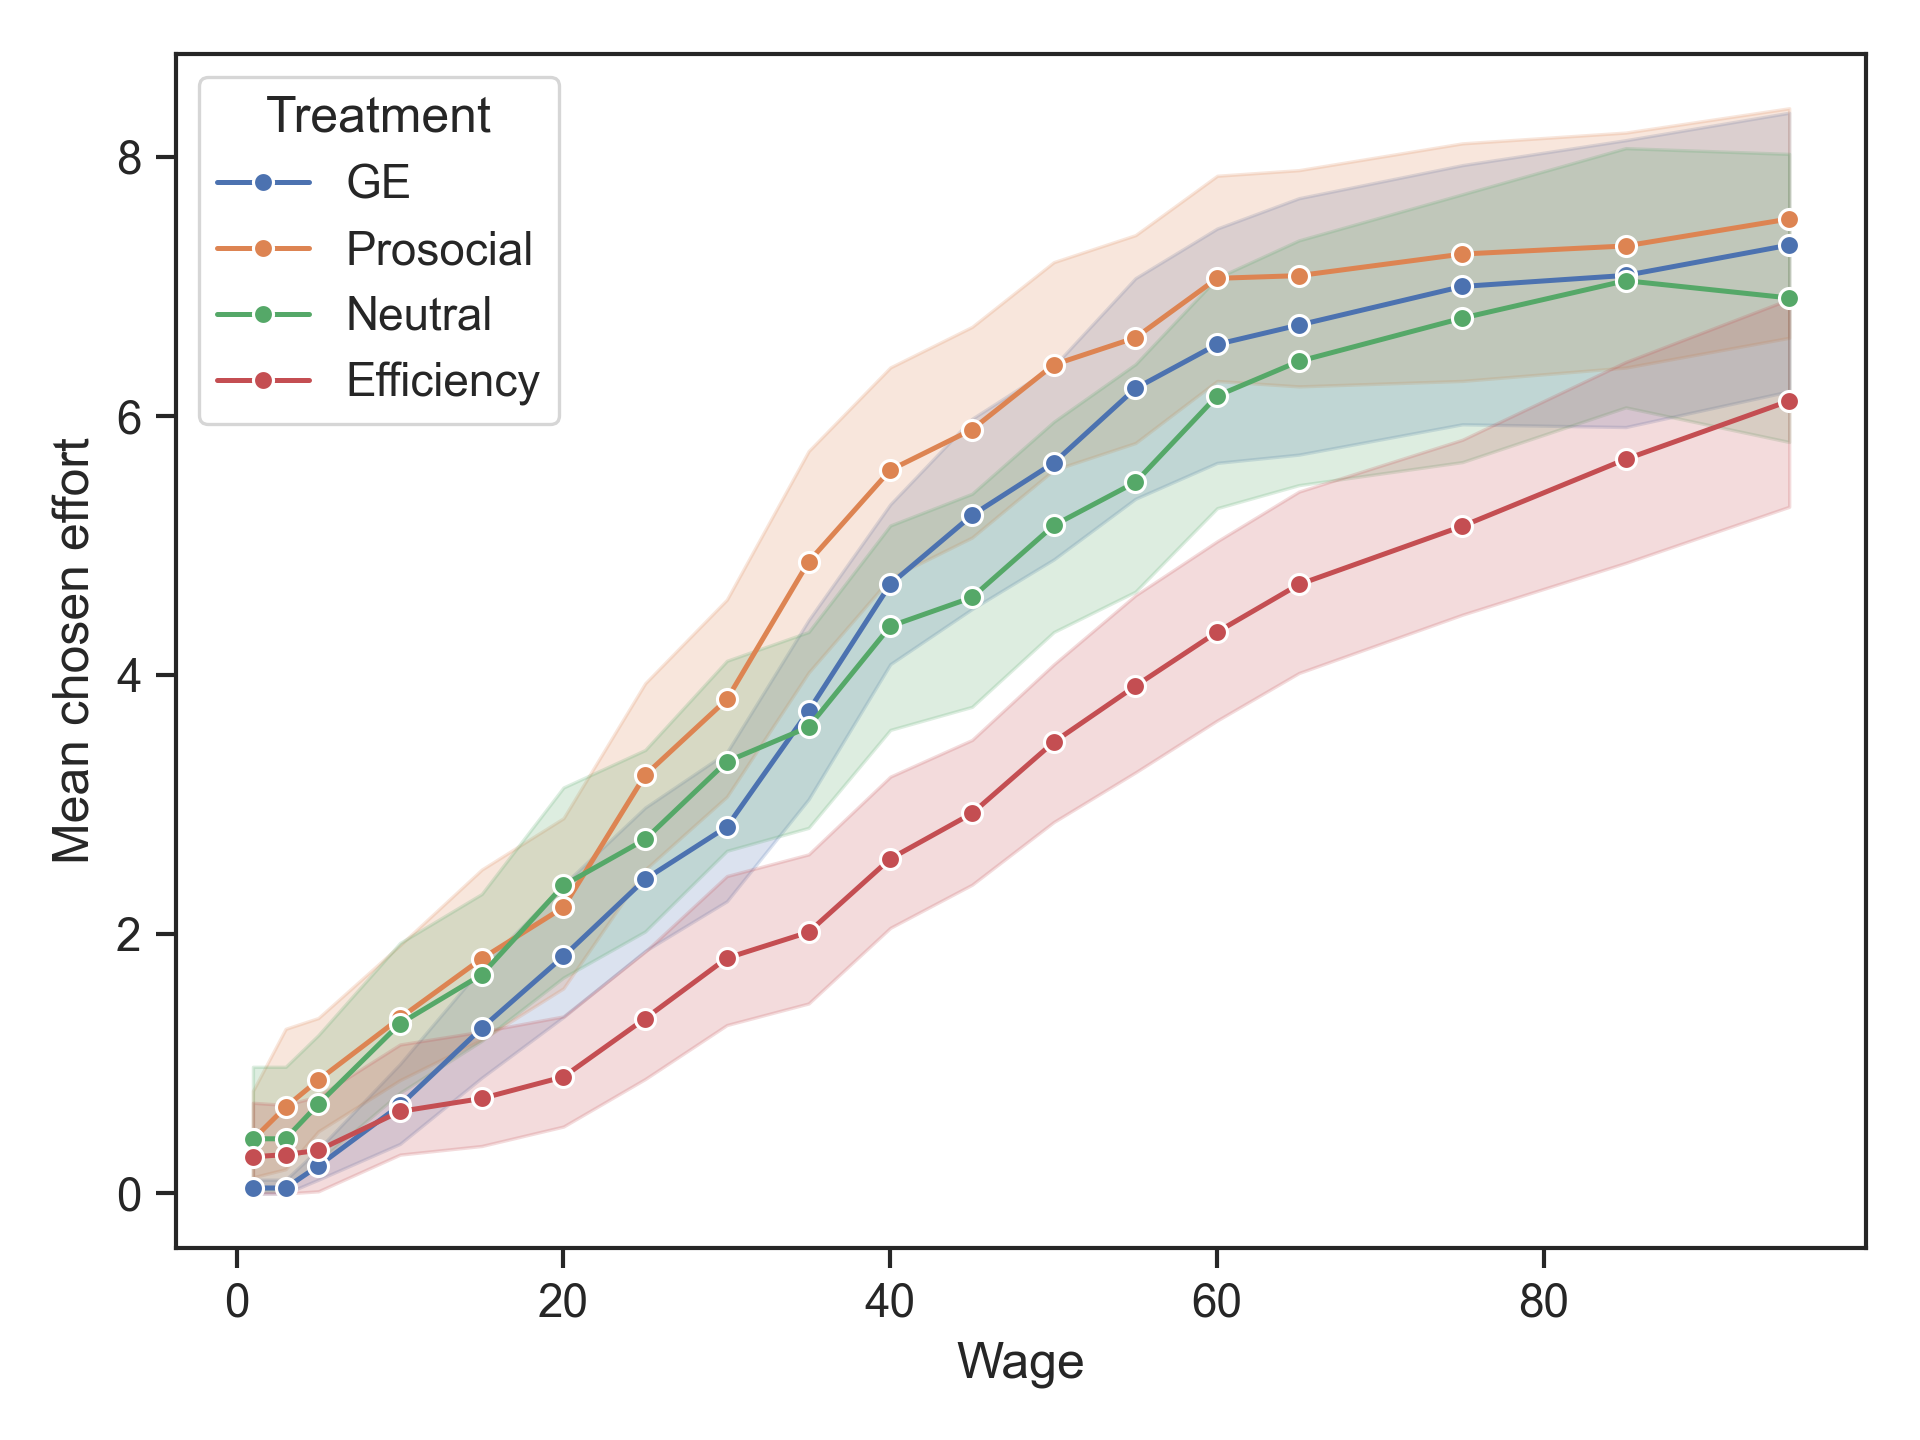

### Figure A.3. Wage comparisons, all treatments

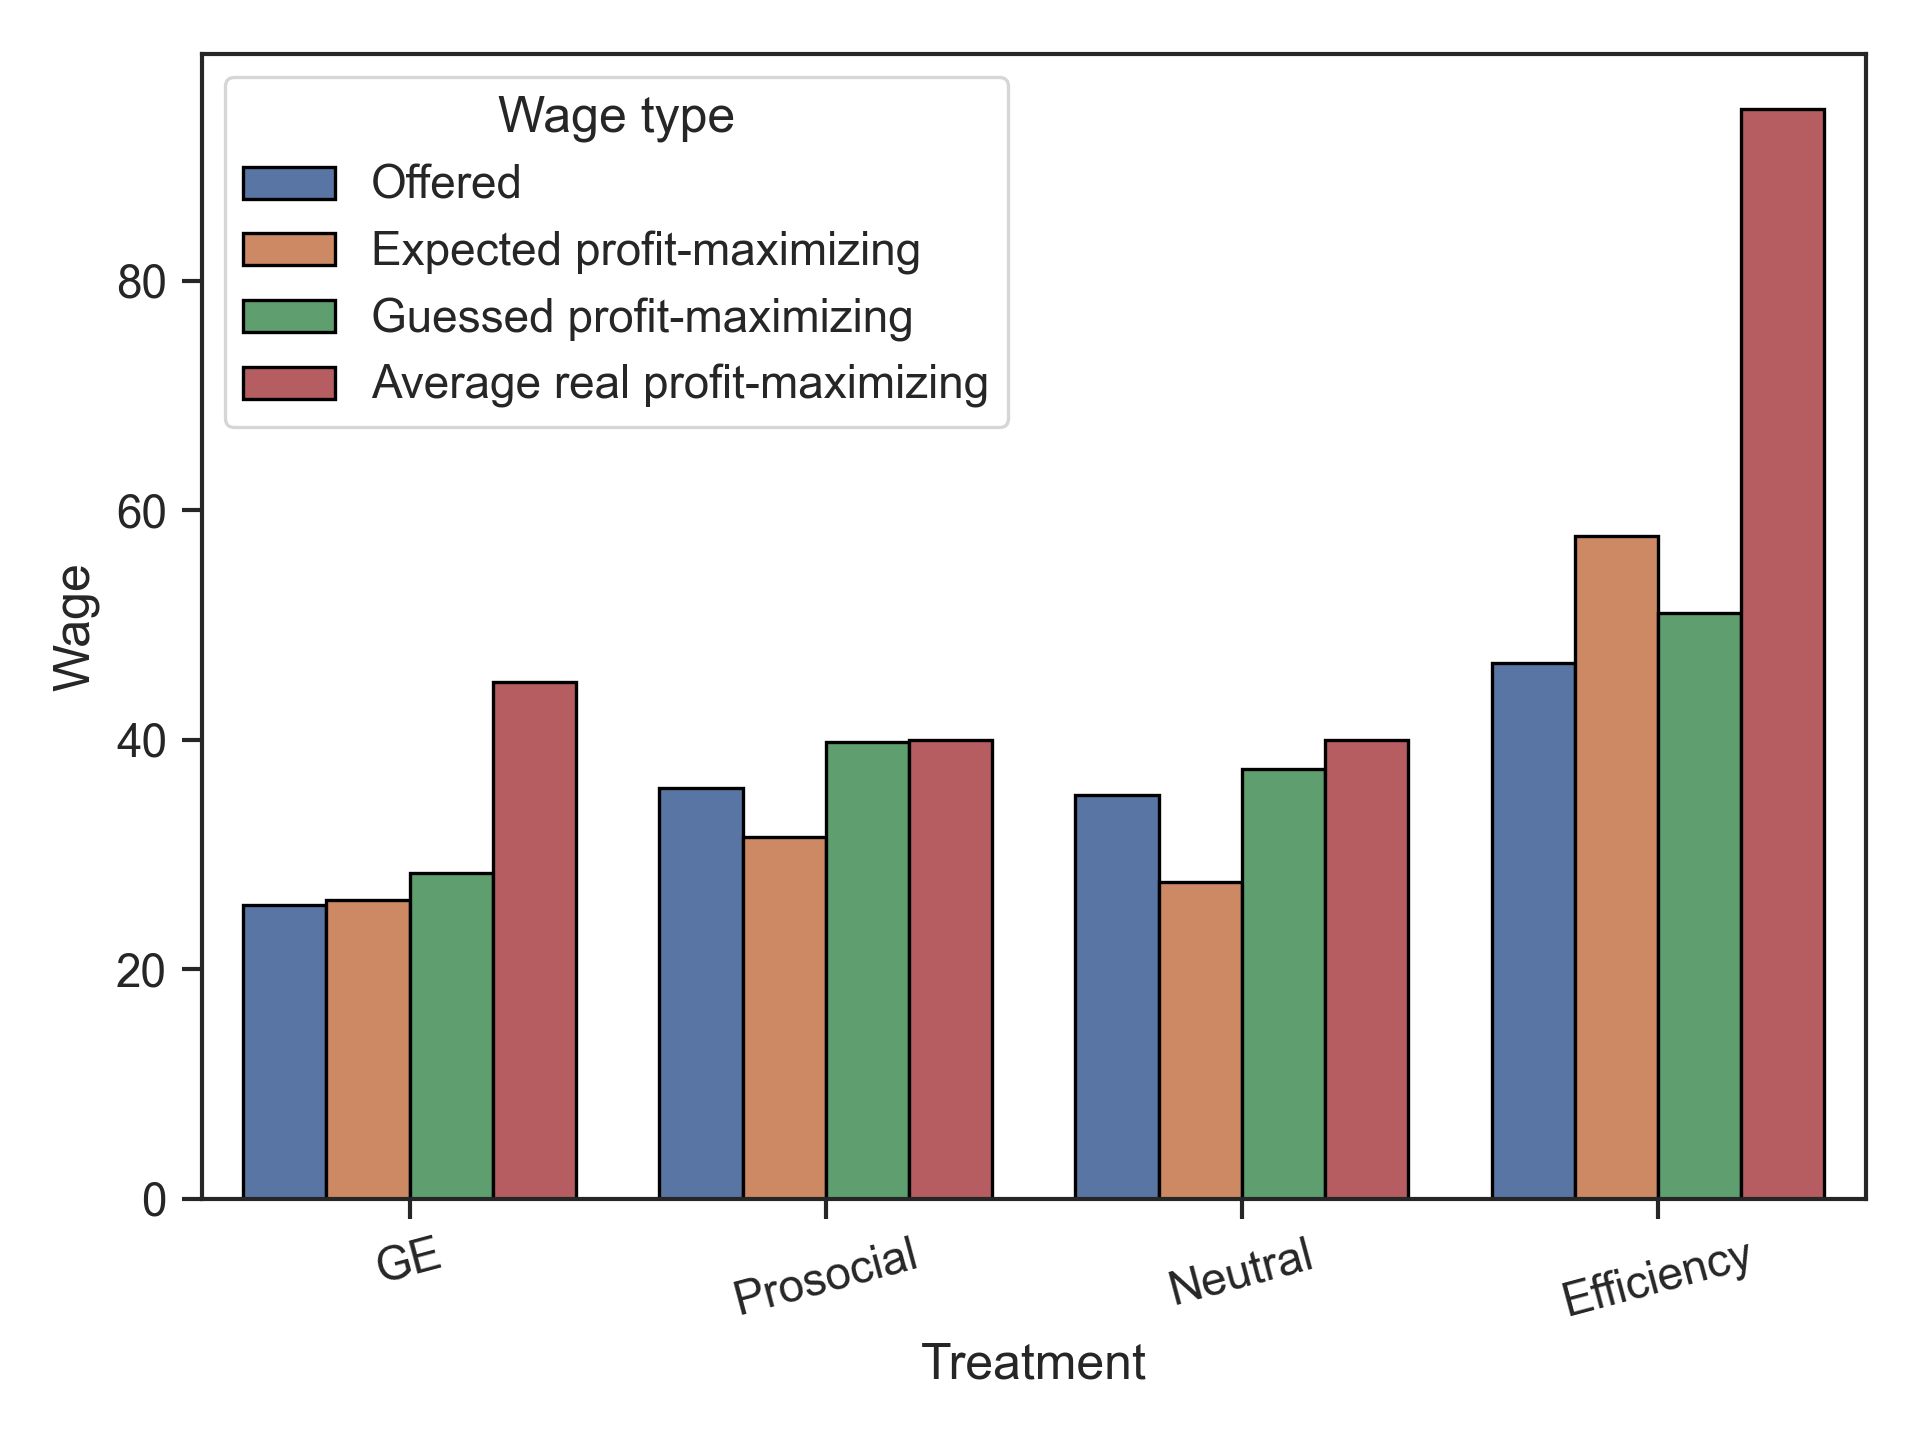

### Figure A.4. Beliefs-based profit-maximizing wage

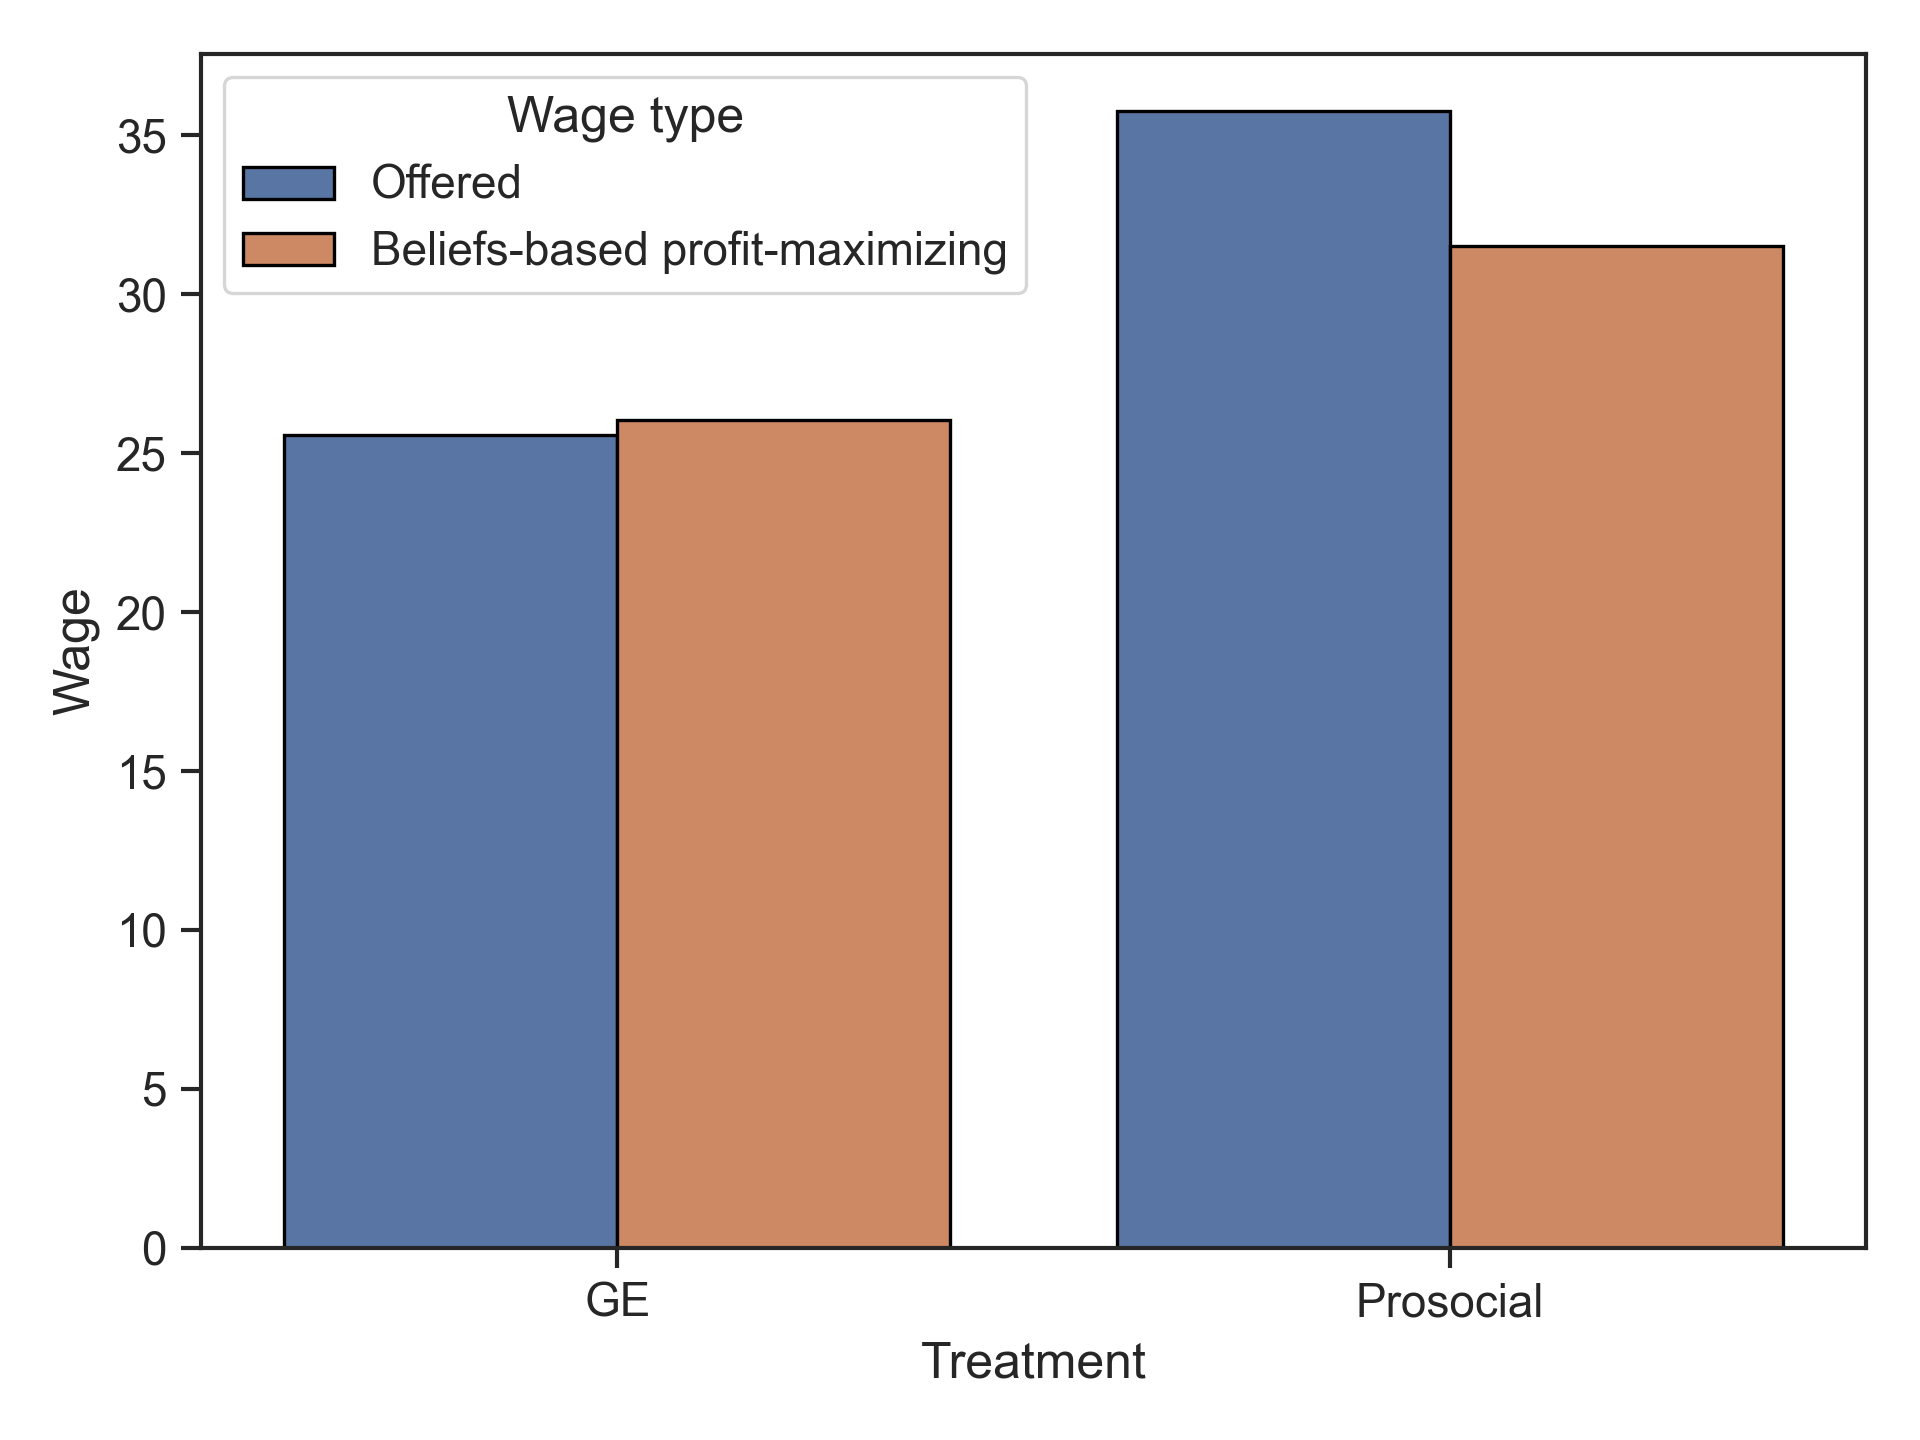

### Figure A.5. Individual effort, GE

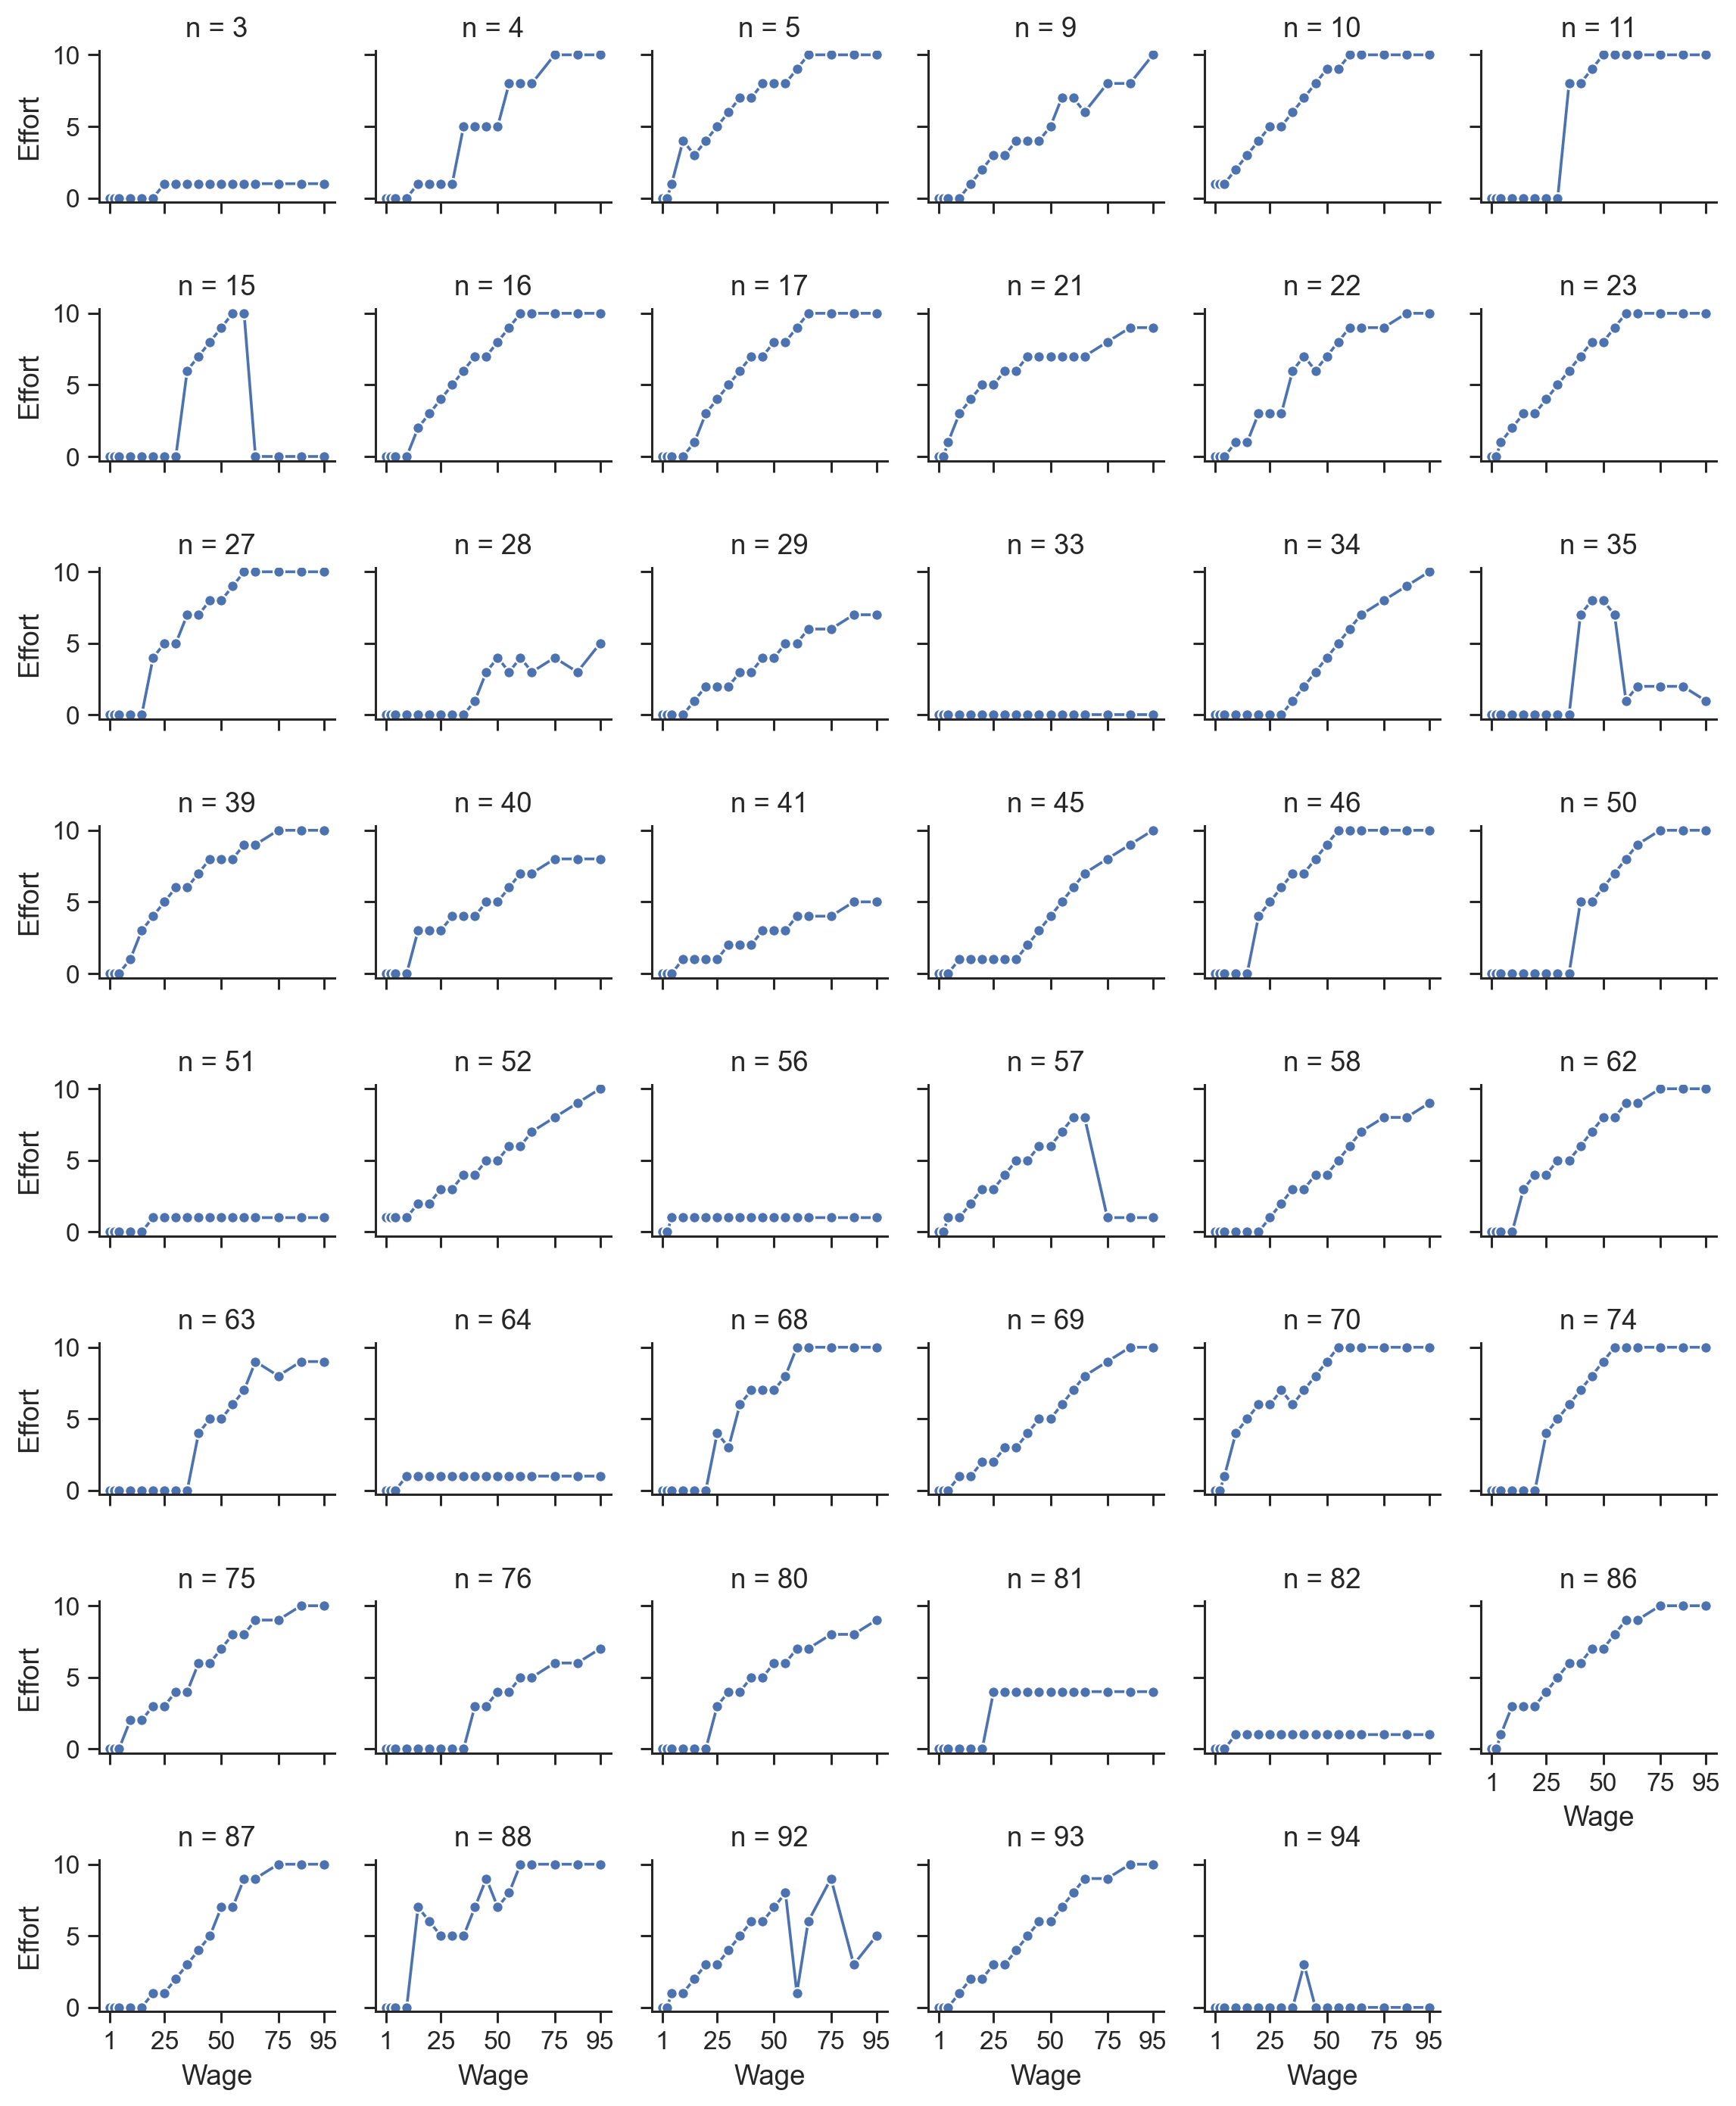

### Figure A.6. Individual effort, prosocial

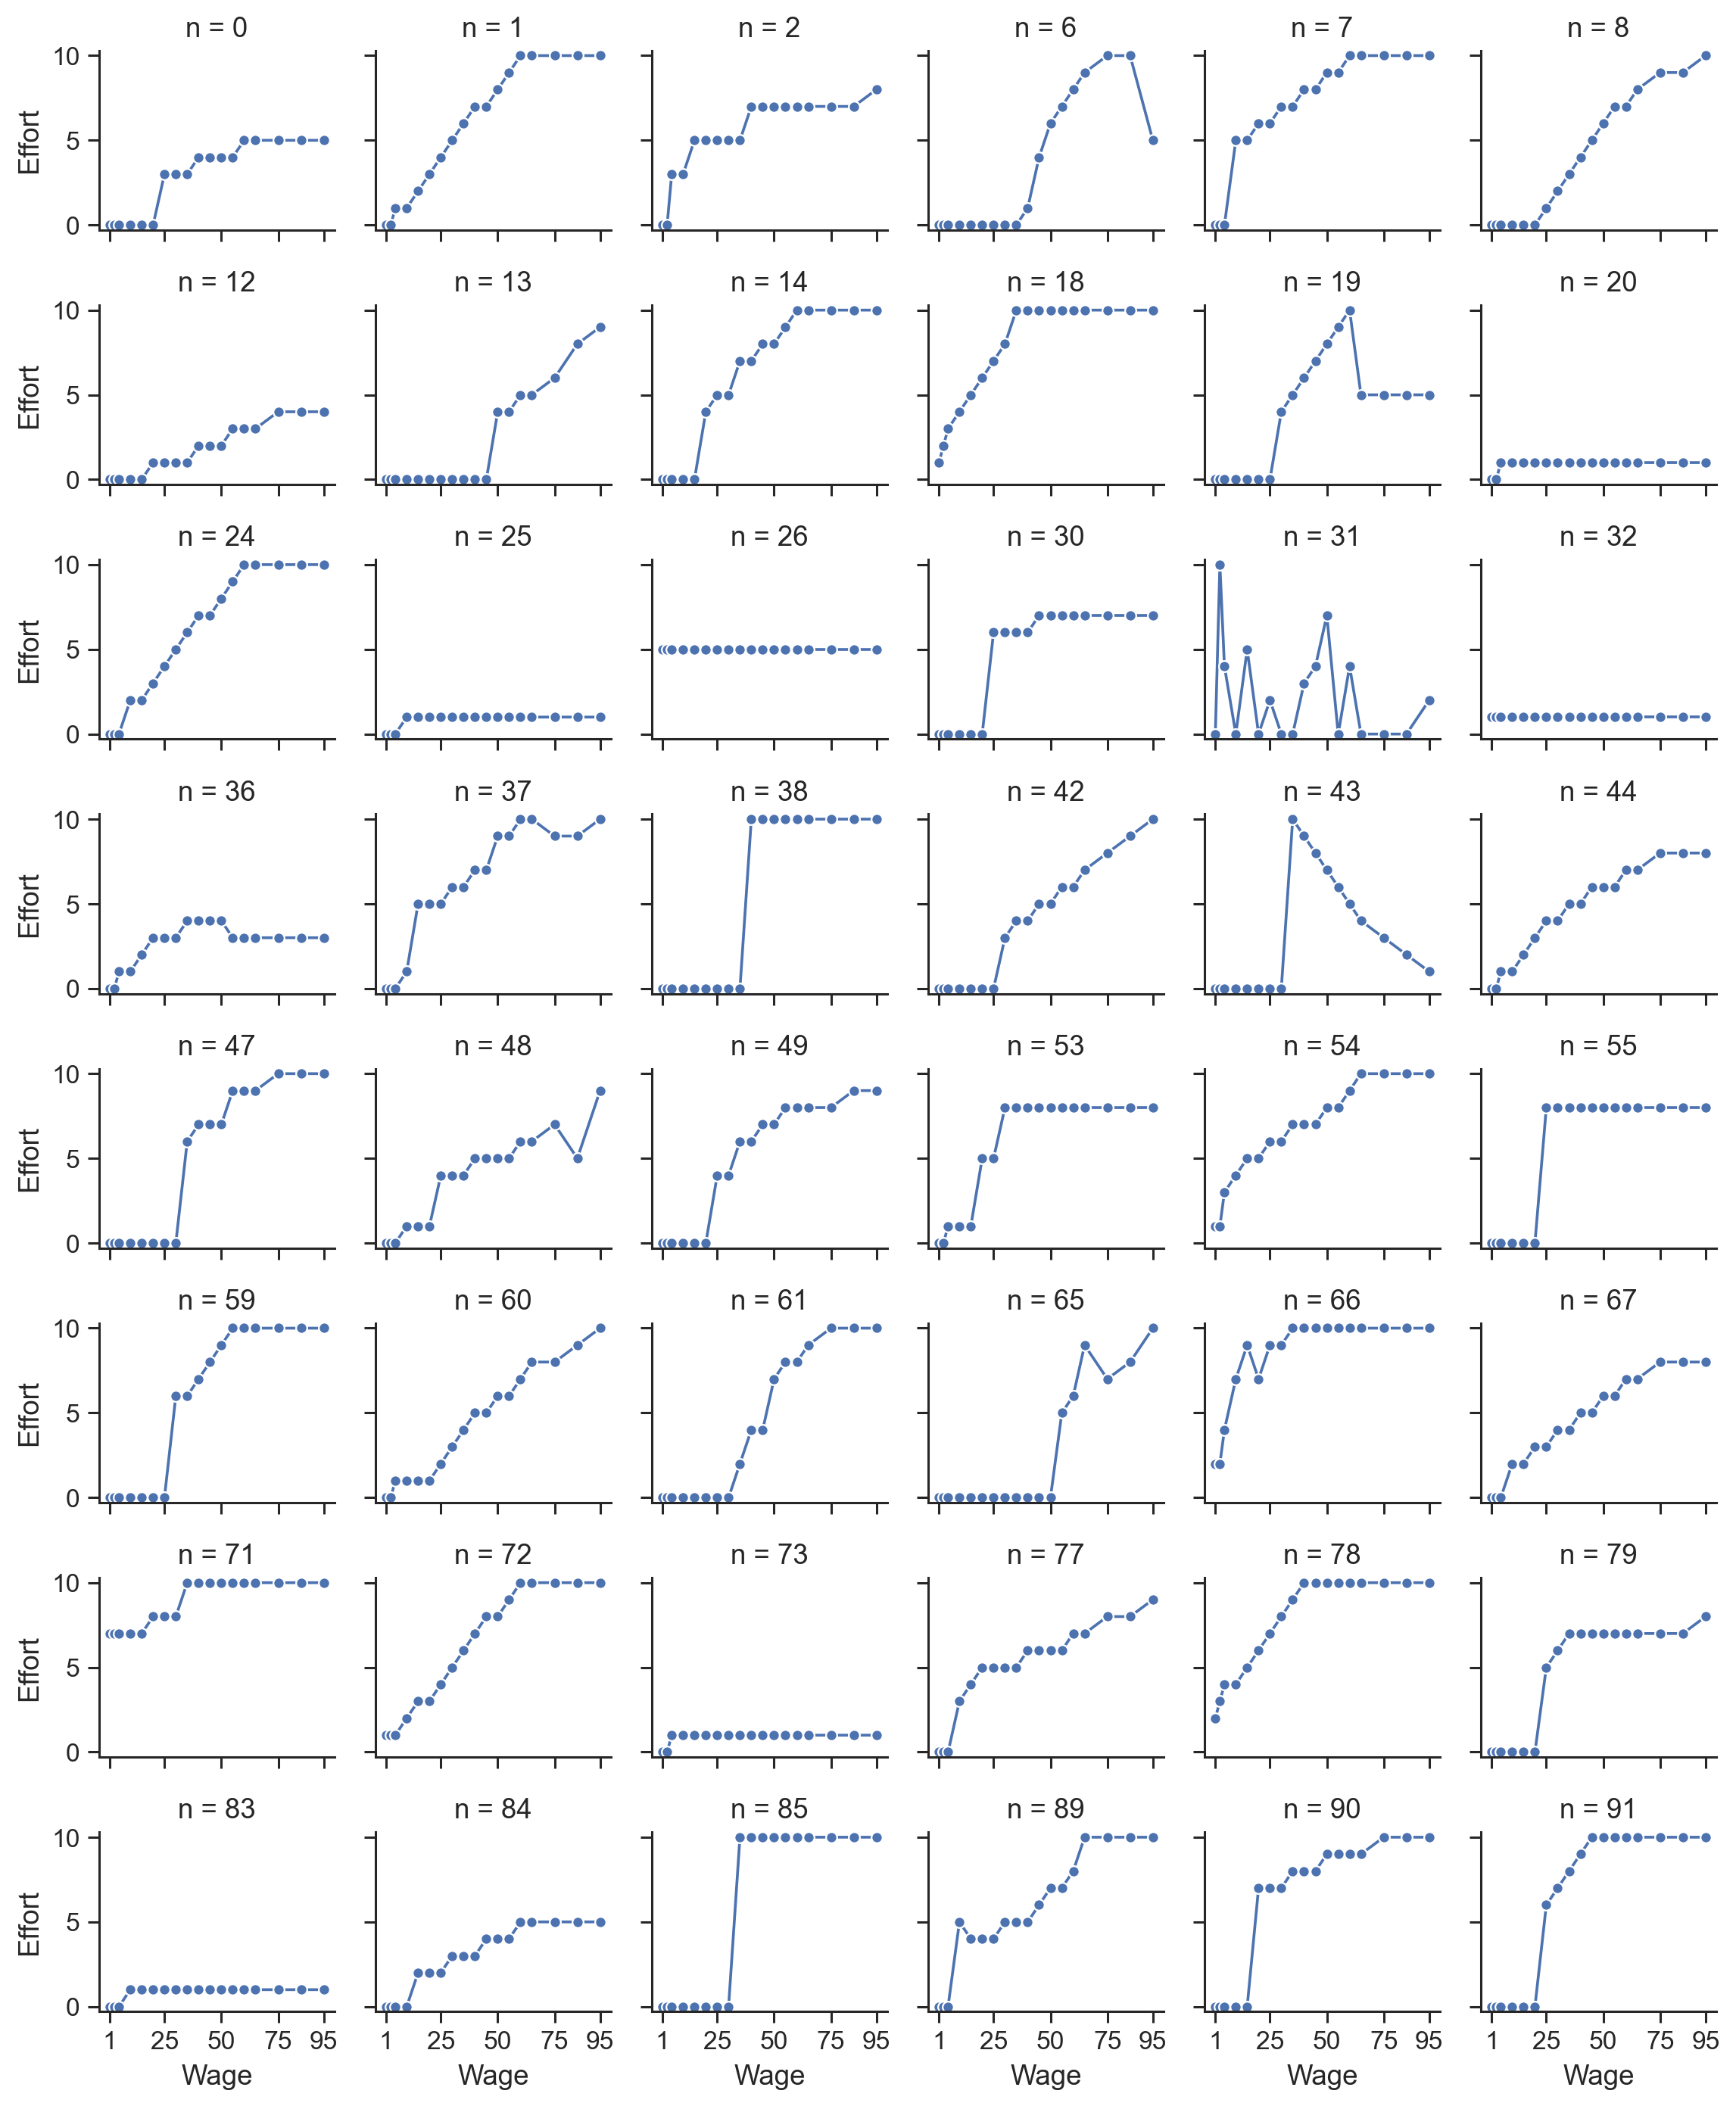

### Figure A.7. Individual effort, neutral

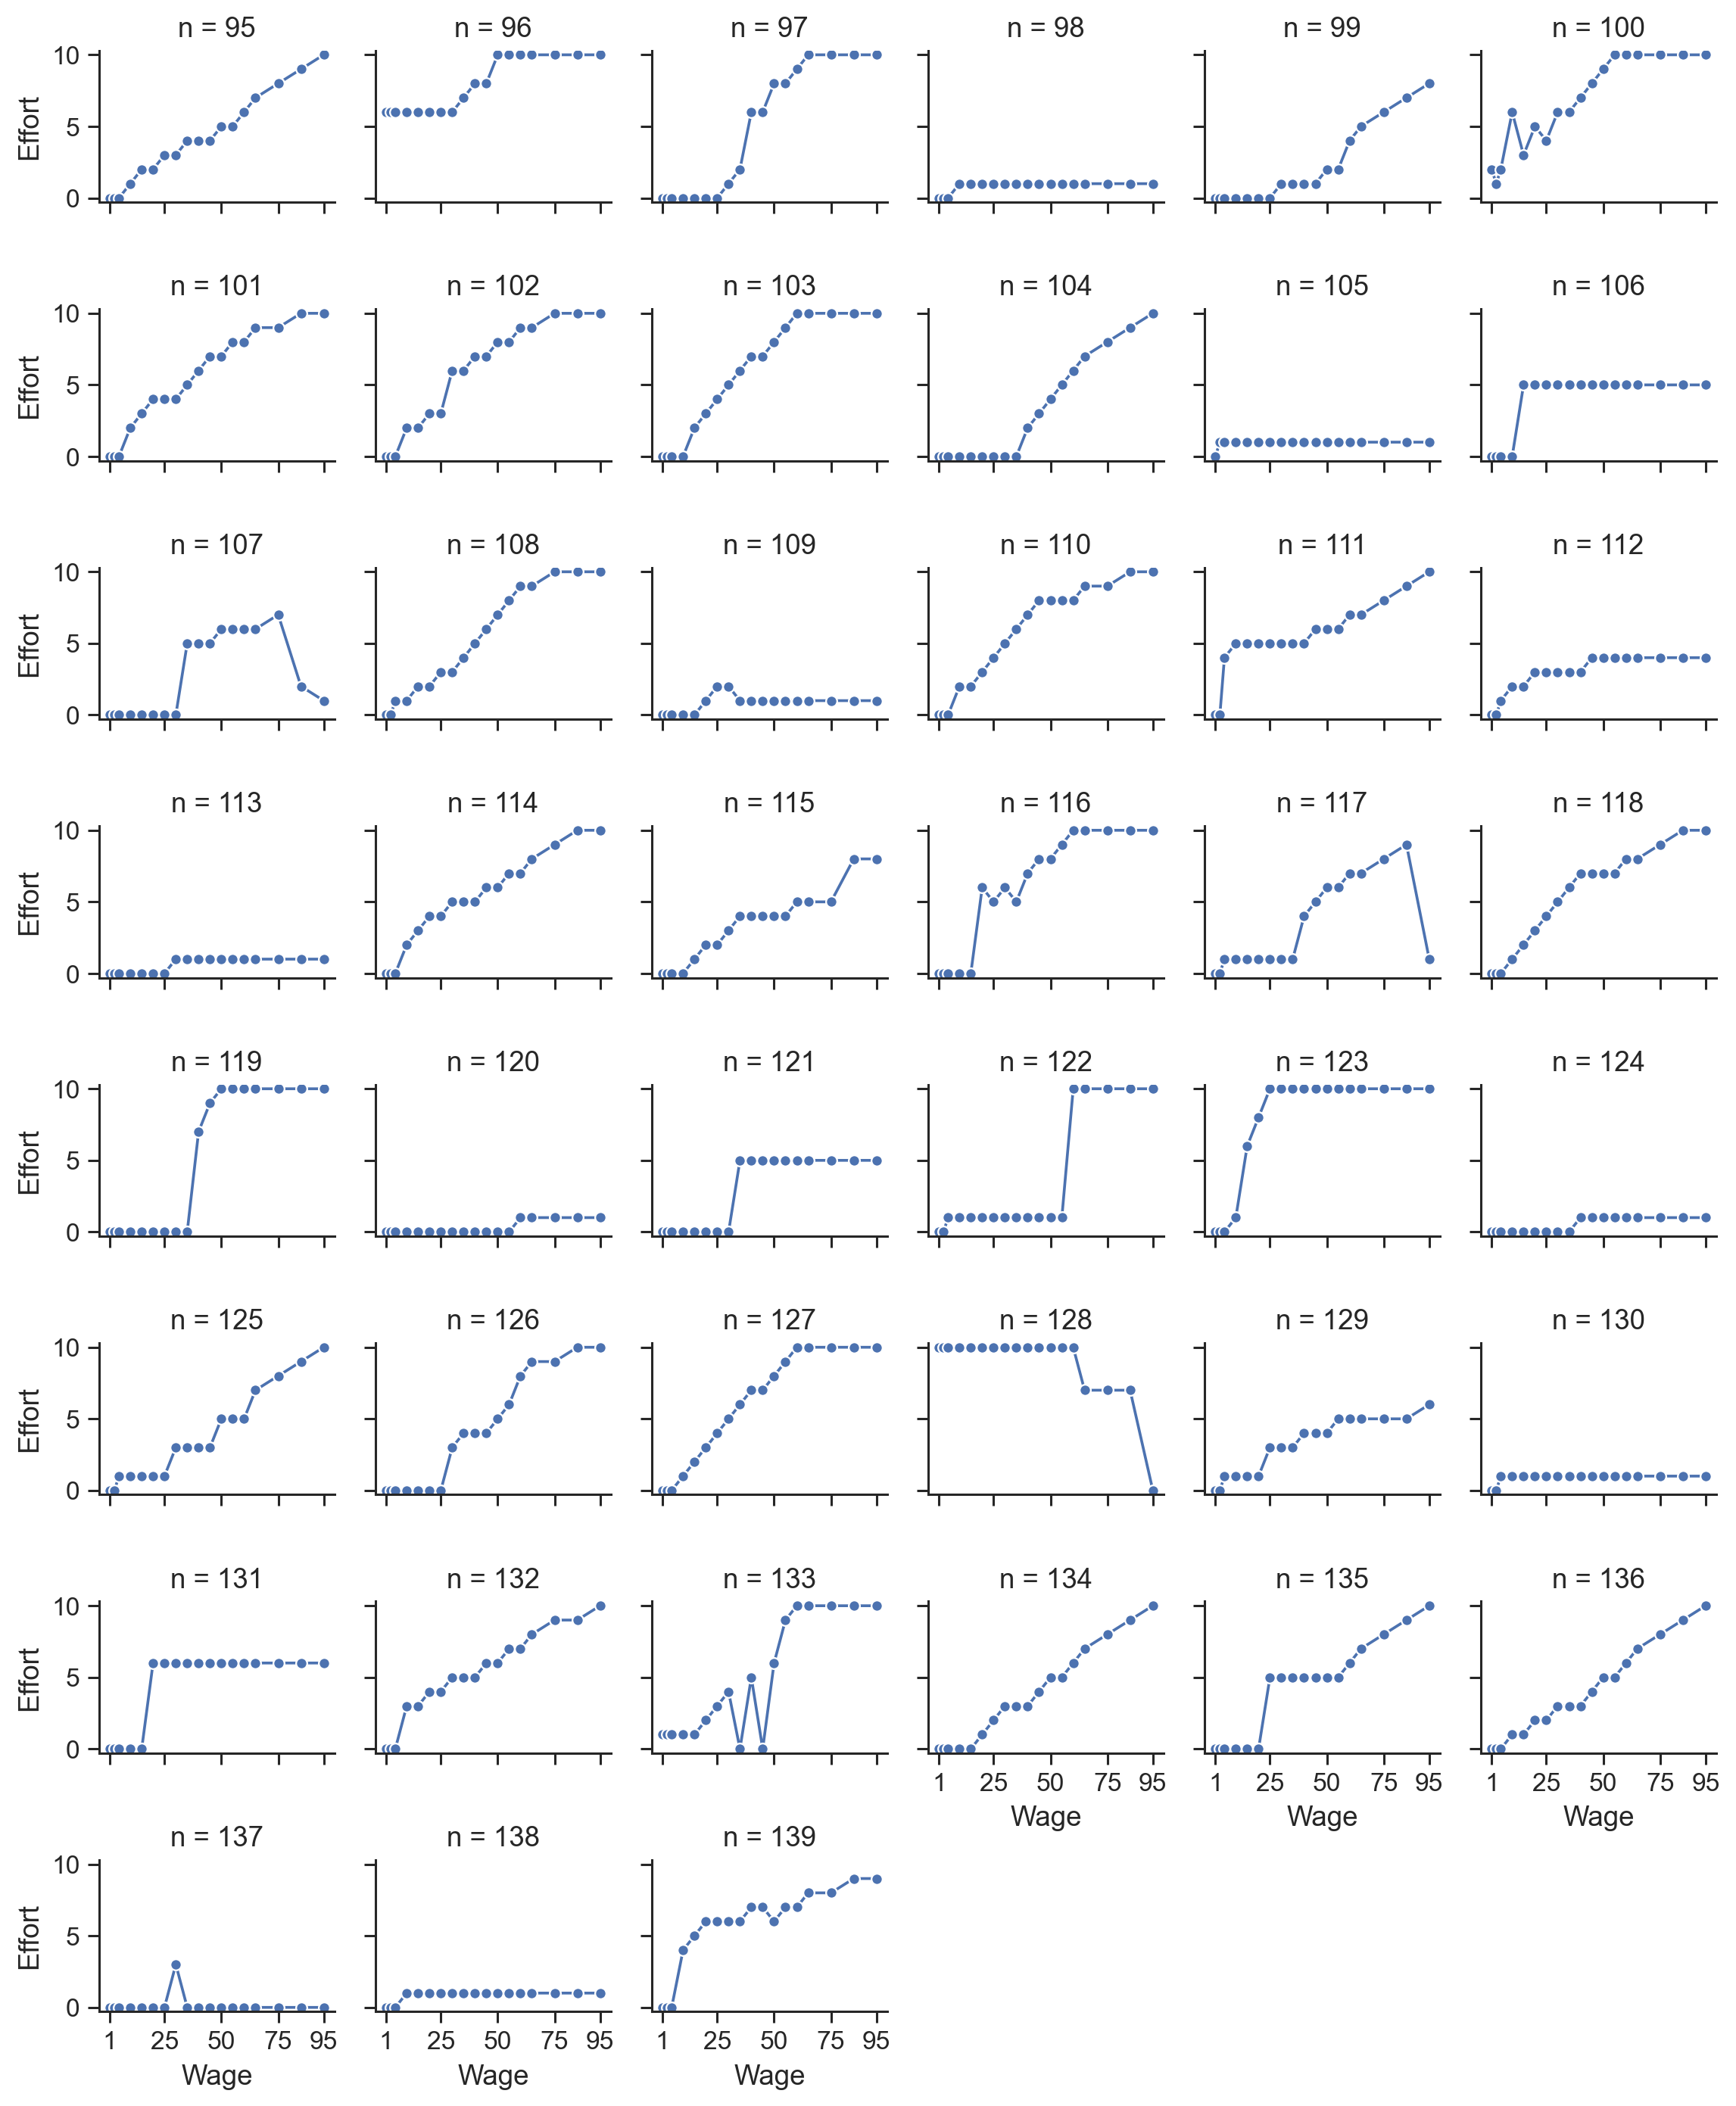

### Figure A.8. Individual effort, efficiency

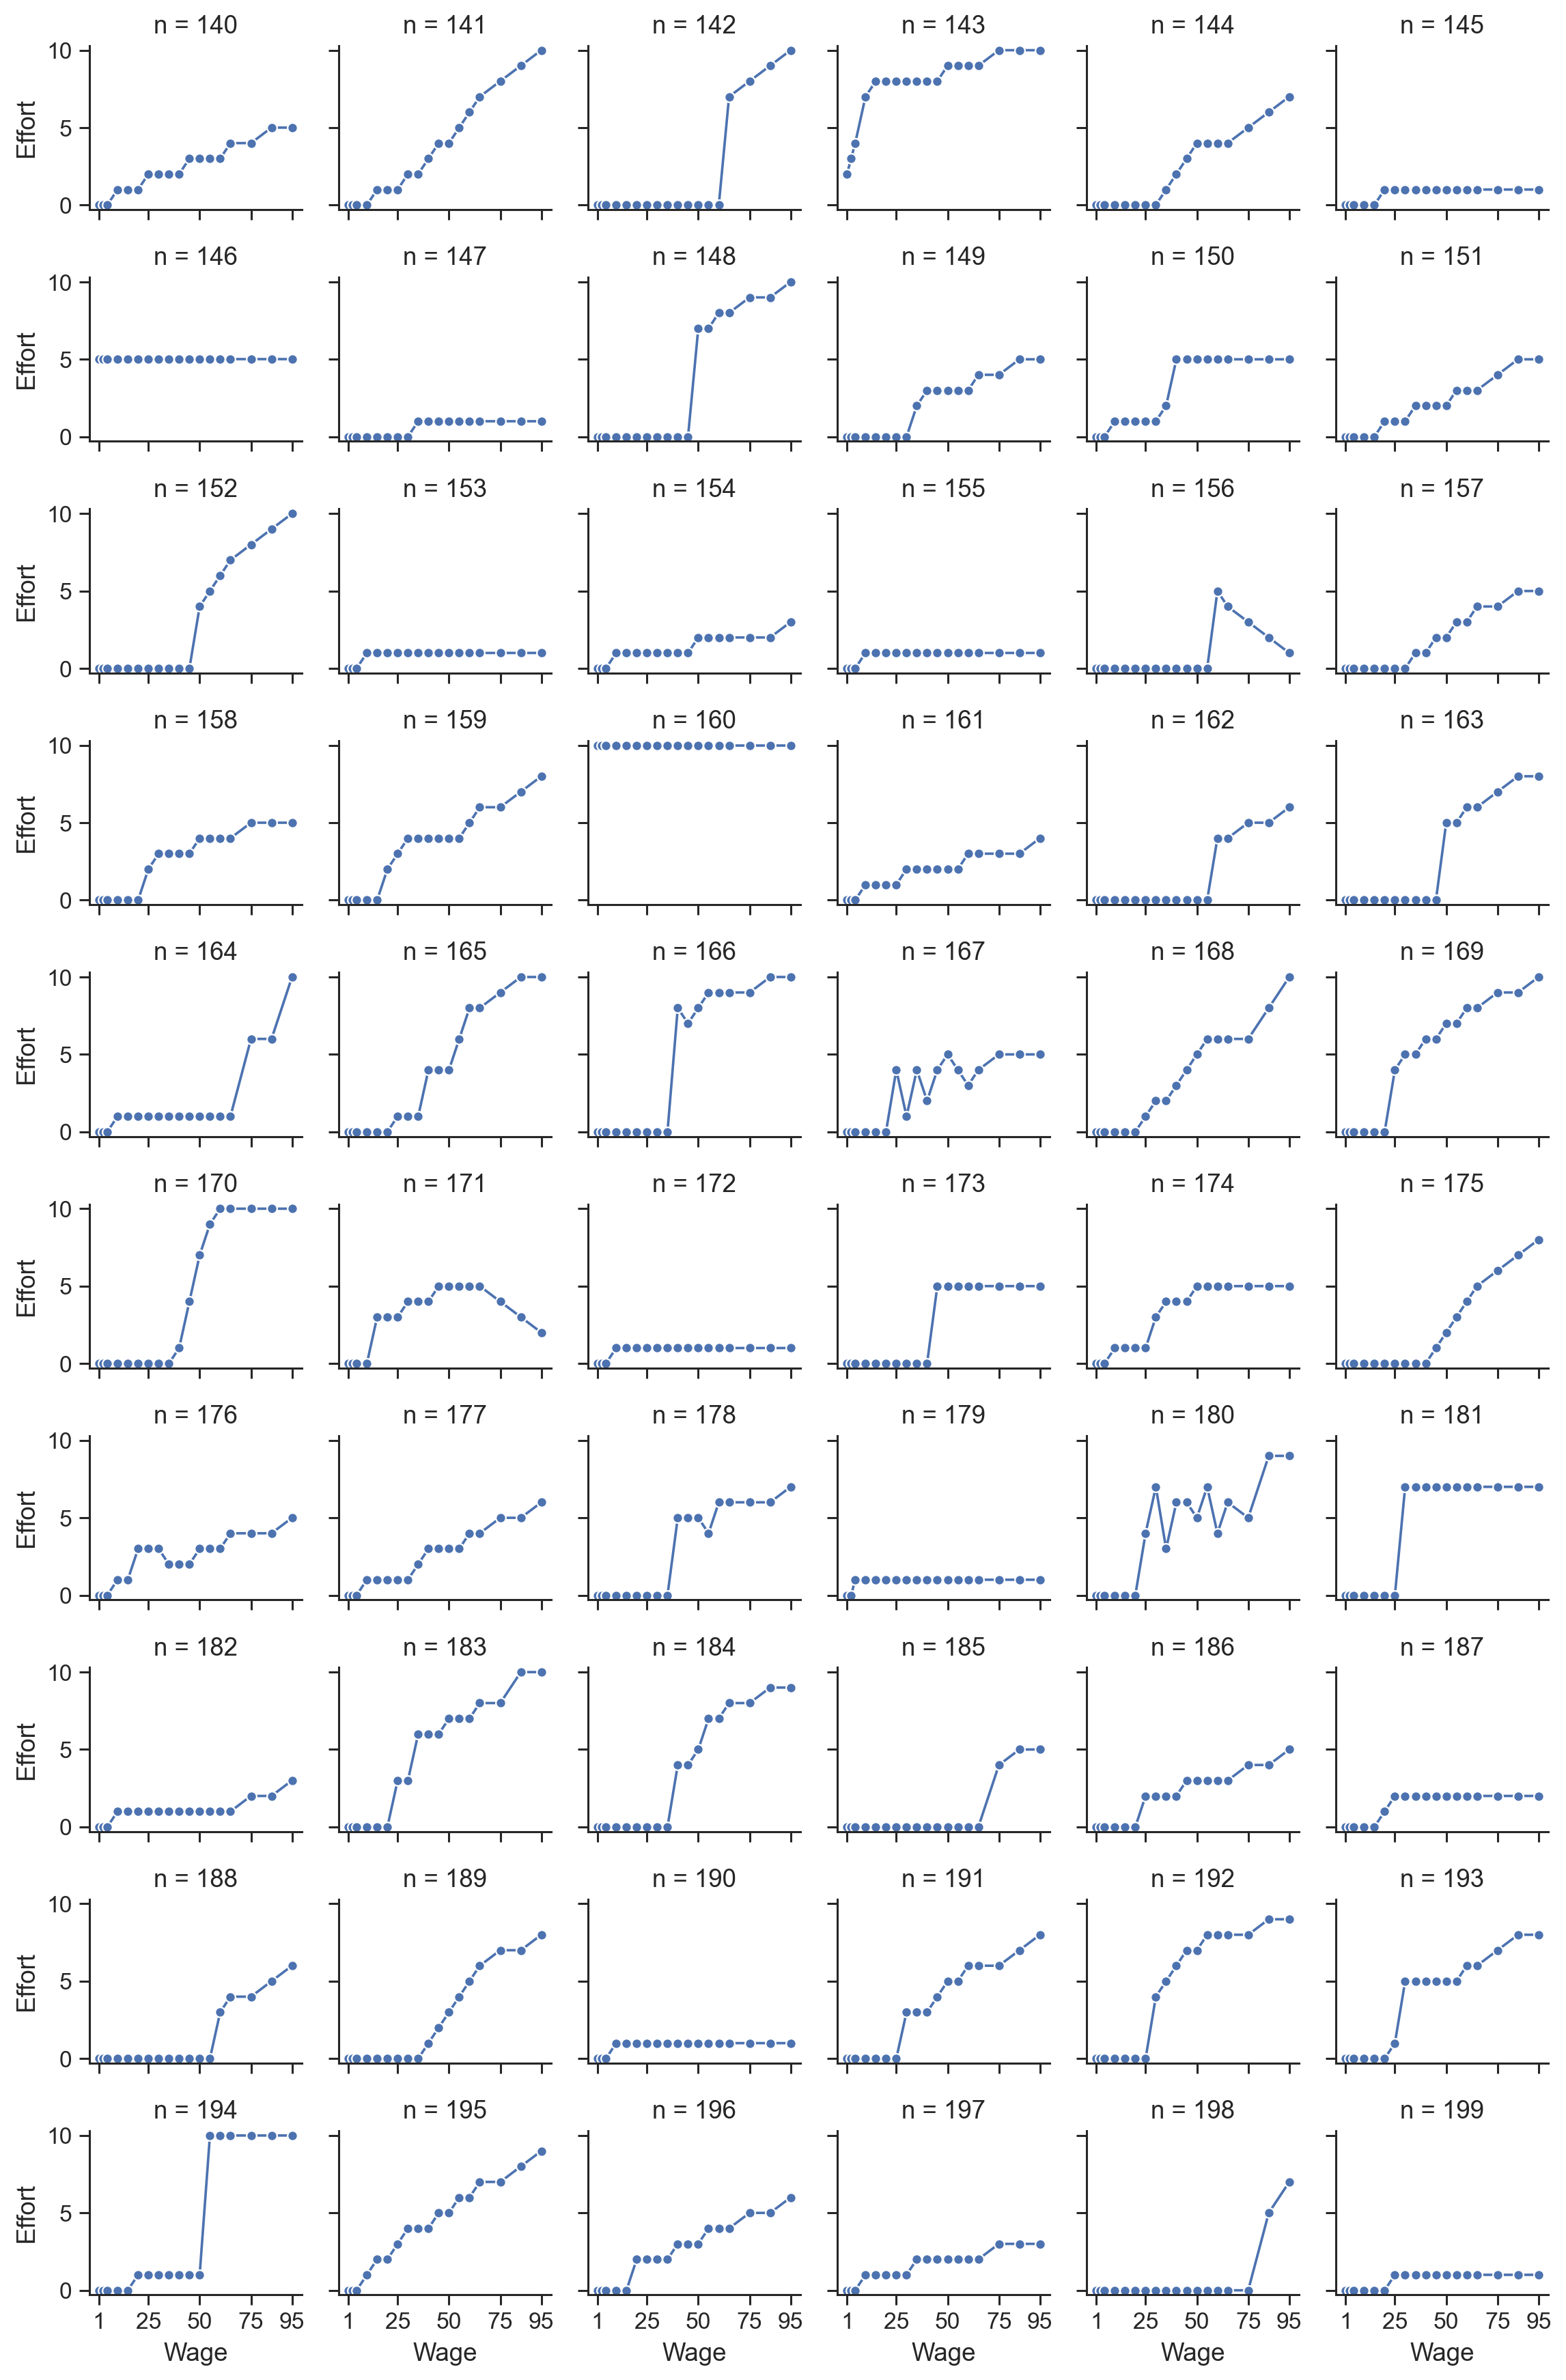

In [10]:
appendix_figures = [
    ("Figure A.1. Acceptance by wage", APPENDIX_FIGURES / "supp_fig_a1_acceptance_wage.png"),
    ("Figure A.2. Chosen effort, all treatments", APPENDIX_FIGURES / "supp_fig_a2_chosen_effort_all.png"),
    ("Figure A.3. Wage comparisons, all treatments", APPENDIX_FIGURES / "supp_fig_a3_wage_comparisons_all.png"),
    ("Figure A.4. Beliefs-based profit-maximizing wage", APPENDIX_FIGURES / "supp_fig_a4_beliefs_based_profitmax_wage.png"),
    ("Figure A.5. Individual effort, GE", APPENDIX_FIGURES / "supp_fig_a5_individual_effort_ge.png"),
    ("Figure A.6. Individual effort, prosocial", APPENDIX_FIGURES / "supp_fig_a6_individual_effort_prosocial.png"),
    ("Figure A.7. Individual effort, neutral", APPENDIX_FIGURES / "supp_fig_a7_individual_effort_neutral.png"),
    ("Figure A.8. Individual effort, efficiency", APPENDIX_FIGURES / "supp_fig_a8_individual_effort_efficiency.png"),
]

for title, path in appendix_figures:
    display(Markdown(f"### {title}"))
    display(Image(filename=str(path)))

## 10. Output Folders

The notebook writes the same researcher-facing outputs as the script workflow.

In [11]:
output_files = sorted(PAPER_TABLES.glob("*.csv")) + sorted(PAPER_FIGURES.glob("*.png")) + sorted(APPENDIX_TABLES.glob("*.csv")) + sorted(APPENDIX_FIGURES.glob("*.png"))
pd.DataFrame({"output": [str(path.relative_to(ROOT)) for path in output_files]})

,output
0,results/paper/tables/table_2_acceptance.csv
1,results/paper/tables/table_3_effort.csv
2,results/paper/tables/table_4_wage_offers.csv
3,results/paper/figures/main_fig_2_chosen_effort...
4,results/paper/figures/main_fig_3_wage_comparis...
5,results/paper/figures/main_fig_4_chosen_expect...
6,results/appendix/tables/table_a1_summary_stati...
7,results/appendix/tables/table_a2_effort_ge_pro...
8,results/appendix/tables/table_a3_effort_neutra...
9,results/appendix/tables/table_a4_acceptance_ne...
